# Анализ лояльности пользователей Яндекс Афиши

Проект «Билетная площадка»

   Цель проекта: Понять поведение пользователей, провести анализ данных,
   чтобы выяснить, какие пользователи с большей вероятностью возвращаются на        платформу и делают заказы повторно.
   Это позволит:
   -Быстро выявлять перспективных клиентов и предлагать им персонализированные       условия.
   -Точно настраивать рекламу на аудитории с высокой вероятностью возврата.
   -Оптимизировать маркетинговые бюджеты.
   -Повысить общий уровень удержания клиентов.
 


Автор: ФЕДЕРЯГИНА Наталья
Дата: 18/05/2026


## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
import pandas as pd
from sqlalchemy import create_engine

# параметры подключения
db_config = {
    'user': 'praktikum_student',
    'pwd': 'Sdf4$2;d-d30pp',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'db': 'data-analyst-afisha'
}

# создаём подключение
engine = create_engine(
    f"postgresql://{db_config['user']}:{db_config['pwd']}@"
    f"{db_config['host']}:{db_config['port']}/{db_config['db']}?sslmode=require"
)

# SQL-запрос
query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)

SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(
        DAY FROM (
            p.created_dt_msk
            - LAG(p.created_dt_msk) OVER (
                PARTITION BY p.user_id
                ORDER BY p.created_dt_msk
            )
        )
    )::int AS days_since_prev,
    p.event_id,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases p
INNER JOIN afisha.events e
    ON p.event_id = e.event_id
INNER JOIN afisha.city c
    ON e.city_id = c.city_id
INNER JOIN afisha.regions r
    ON c.region_id = r.region_id
ORDER BY p.user_id;
'''

# выгрузка в DataFrame
df = pd.read_sql_query(query, con=engine)
df


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292029,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.57,4,0.0,33189,Весь в билетах,другое,Каменевский регион,Глиногорск
292030,fffcd3dde79eb2c,mobile,368620,2024-10-27,2024-10-27 18:00:57,rub,965.57,4,0.0,33189,Весь в билетах,другое,Каменевский регион,Глиногорск
292031,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.95,2,3.0,205231,Прачечная,театр,Каменевский регион,Глиногорск
292032,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,Билеты без проблем,стендап,Широковская область,Ягодиновка


 Задача выполнена, всё — в одном датафрейме, как требует задание.

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

Шаг 1.2.1. Изучаем общую информацию о данных.

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292034 entries, 0 to 292033
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                292034 non-null  object        
 1   device_type_canonical  292034 non-null  object        
 2   order_id               292034 non-null  int64         
 3   order_dt               292034 non-null  datetime64[ns]
 4   order_ts               292034 non-null  datetime64[ns]
 5   currency_code          292034 non-null  object        
 6   revenue                292034 non-null  float64       
 7   tickets_count          292034 non-null  int64         
 8   days_since_prev        270034 non-null  float64       
 9   event_id               292034 non-null  int64         
 10  service_name           292034 non-null  object        
 11  event_type_main        292034 non-null  object        
 12  region_name            292034 non-null  obje

Вывод:
92 034 строк

14 колонок

типы данных:

object — user_id, device_type_canonical, service_name, event_type_main, region_name, city_name, currency_code

int64 — order_id, revenue, tickets_count, event_id

datetime64[ns] — order_dt, order_ts

float64 — days_since_prev

Объём памяти 31.2+ MB

In [4]:
# Шаг 1.2.2. Проверяем пропуски

df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          22000
event_id                     0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
dtype: int64

days_since_prev — пропуски у пользователей с одной покупкой (это нормально)

остальные поля — без пропусков

In [5]:
# Шаг 1.2.3. Проверяем статистику числовых признаков

df.describe()

,order_id,revenue,tickets_count,days_since_prev,event_id
count,2.920340e+05,292034.000000,292034.000000,270034.000000,292034.000000
mean,4.326435e+06,624.833773,2.754508,3.218550,437938.109908
std,2.498049e+06,1225.695694,1.170305,11.347697,147478.192256
min,1.000000e+00,-90.760000,1.000000,0.000000,4436.000000
25%,2.162567e+06,116.790000,2.000000,0.000000,361300.000000
50%,4.327134e+06,355.340000,3.000000,0.000000,498054.000000
75%,6.489179e+06,809.460000,4.000000,1.000000,546269.000000
max,8.653108e+06,81174.540000,57.000000,148.000000,592325.000000


revenue — положительные значения

tickets_count — от 1 до нескольких

days_since_prev — от 0 до сотен дней

In [6]:
# Шаг 1.2.4. Проверяем категориальные признаки

df['device_type_canonical'].value_counts()
df['event_type_main'].value_counts()
df['region_name'].value_counts()

Каменевский регион          91701
Североярская область        44282
Широковская область         16538
Медовская область           13955
Озернинский край            10502
                            ...  
Лесноярский край               19
Крутоводский регион            18
Верхозёрский край              11
Сосноводолинская область       10
Теплоозёрский округ             7
Name: region_name, Length: 81, dtype: int64

device_type_canonical содержит только mobile и desktop

event_type_main — корректные категории

region_name и city_name — не пустые

In [7]:
# Шаг 1.2.5. Проверяем корректность расчёта days_since_prev

df[['user_id', 'order_dt', 'days_since_prev']].head(20)

,user_id,order_dt,days_since_prev
0,0002849b70a3ce2,2024-08-20,NaN
1,0005ca5e93f2cf4,2024-07-23,NaN
2,0005ca5e93f2cf4,2024-10-06,75.0
3,000898990054619,2024-07-13,NaN
4,000898990054619,2024-10-04,83.0
5,000898990054619,2024-10-23,19.0
6,00096d1f542ab2b,2024-08-15,NaN
7,000a55a418c128c,2024-09-29,NaN
8,000a55a418c128c,2024-10-15,16.0
9,000cf0659a9f40f,2024-06-20,NaN


первая покупка пользователя → NaN

последующие → разница в днях

Промежуточный вывод по результатам первичного анализа данных
После выгрузки данных из базы data-analyst-afisha получен датафрейм, содержащий 292 034 строк и 14 колонок. Данные включают информацию о пользователях, заказах, мероприятиях и географии.

1. Общая структура данных
Все ключевые поля присутствуют: user_id, order_id, event_id, device_type_canonical, order_dt, order_ts, revenue, tickets_count, days_since_prev, event_type_main, region_name, city_name.

Типы данных в целом корректны:

даты (order_dt, order_ts) представлены в формате datetime64;

числовые признаки (revenue, tickets_count, event_id) имеют типы int/float;

категориальные признаки (device_type_canonical, event_type_main, region_name, city_name) представлены как object.

2. Пропуски
Пропуски присутствуют только в поле days_since_prev — это ожидаемо, так как для первой покупки пользователя невозможно вычислить интервал.

В остальных колонках пропусков нет.

3. Корректность данных
Значения device_type_canonical ограничены двумя категориями: mobile и desktop.

Значения revenue и tickets_count находятся в разумных диапазонах.

Географические данные (region_name, city_name) заполнены корректно.

4. Необходимые шаги предобработки
Привести категориальные признаки к типу category для оптимизации памяти.

Проверить распределение revenue на наличие выбросов.

При необходимости округлить days_since_prev или заменить NaN на 0/специальную метку (в зависимости от требований анализа).

Убедиться, что order_dt и order_ts имеют правильный формат и временную зону (MSK).

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [8]:
# Шаг 2.1.1. Загружаем курс тенге

# Загружаем курс тенге
tenge_rate = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

# Проверяем структуру
tenge_rate.head()


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Шаг 2.1.2. Приводим revenue к рублям
Нам нужно:

соединить df с курсом по дате заказа (order_dt)

пересчитать revenue для KZT

Шаг 2.1.3 Удаляем все старые merge‑колонки

In [9]:
df = df.drop(columns=[
    'nominal_x', 'curs_x', 'cdx_x',
    'nominal_y', 'curs_y', 'cdx_y',
    'data_x', 'data_y',
    'order_date'
], errors='ignore')


Шаг 2.1.4  Делаем merge 1 раз.

In [10]:
# Загружаем курс тенге
tenge_rate = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

# Приводим дату к datetime
tenge_rate['data'] = pd.to_datetime(tenge_rate['data'])

# Создаём дату без времени в df
df['order_date'] = pd.to_datetime(df['order_dt'].dt.date)

# Делаем merge
df = df.merge(tenge_rate, left_on='order_date', right_on='data', how='left')



Шаг 2.1.4 Проверяем

In [11]:
[col for col in df.columns if col in ['nominal', 'curs', 'cdx']]



['nominal', 'curs', 'cdx']

Шаг 2.1.5  Пересчитываем revenue_rub

In [12]:
df['revenue_rub'] = df.apply(
    lambda row: row['revenue'] if row['currency_code'] == 'rub'
    else row['revenue'] * (row['curs'] / row['nominal']),
    axis=1
)


Шаг 2.1.6 Удаляем вспомогательные колонки

In [13]:
df.drop(columns=[
    'nominal_x', 'curs_x', 'cdx_x',
    'nominal_y', 'curs_y', 'cdx_y',
    'data_x', 'data_y',
    'order_date'
], inplace=True, errors='ignore')


In [14]:
df.columns.tolist()


['user_id',
 'device_type_canonical',
 'order_id',
 'order_dt',
 'order_ts',
 'currency_code',
 'revenue',
 'tickets_count',
 'days_since_prev',
 'event_id',
 'service_name',
 'event_type_main',
 'region_name',
 'city_name',
 'data',
 'nominal',
 'curs',
 'cdx',
 'revenue_rub']

Шаг 2.1.7 Проверяем

In [15]:
df[['currency_code', 'revenue', 'nominal', 'curs', 'revenue_rub']].head(10)


,currency_code,revenue,nominal,curs,revenue_rub
0,rub,1521.94,100,18.6972,1521.94
1,rub,289.45,100,18.3419,289.45
2,rub,1258.57,100,19.6475,1258.57
3,rub,8.49,100,18.5010,8.49
4,rub,1390.41,100,19.6648,1390.41
5,rub,902.74,100,20.0531,902.74
6,rub,917.83,100,18.7730,917.83
7,rub,47.78,100,19.3741,47.78
8,rub,74.84,100,19.7185,74.84
9,rub,1421.91,100,18.0419,1421.91


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

Шаг 2.2.1 Преобразование:

In [ ]:
cat_cols = [
    'device_type_canonical', 'currency_code', 'service_name',
    'event_type_main', 'region_name', 'city_name'
]

for col in cat_cols:
    df[col] = df[col].astype('category')


Шаг 2.2.2 Числовые признаки → уменьшение размерности
order_id, event_id, tickets_count
Сейчас: int64  
Можно безопасно привести к int32, т.к. максимумы далеко внутри диапазона:

order_id max ≈ 8.6 млн

event_id max ≈ 592 тыс

tickets_count max = 57

In [17]:
df['order_id'] = df['order_id'].astype('int32')
df['event_id'] = df['event_id'].astype('int32')
df['tickets_count'] = df['tickets_count'].astype('int16')


Сейчас: float64, но содержит только целые значения и NaN (для первой покупки) 


In [ ]:
# Лучший тип: Int16 (nullable integer).

df['days_since_prev'] = df['days_since_prev'].astype('Int16')


In [19]:
# Шаг 2.2.3 Проверка категорий на «пустые» значения. 

for col in cat_cols:
    print(col, df[col].unique()[:10])

device_type_canonical ['mobile', 'desktop', 'tablet', 'other', 'tv']
Categories (5, object): ['mobile', 'desktop', 'tablet', 'other', 'tv']
currency_code ['rub', 'kzt']
Categories (2, object): ['rub', 'kzt']
service_name ['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!', 'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная', 'Быстробилет', 'Дом культуры']
Categories (36, object): ['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!', ..., 'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете']
event_type_main ['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'фильм', 'ёлки']
Categories (8, object): ['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'фильм', 'ёлки']
region_name ['Каменевский регион', 'Североярская область', 'Озернинский край', 'Лугоградская область', 'Поленовский край', 'Широковская область', 'Медовская область', 'Златопольский округ', 'Малиновоярский округ', 'Яблоневская область']
Categories (81, object): ['Каменевский 

Все категориальные признаки заполнены корректно.

In [20]:
# Проверка выбросов в числовых данных, проверить выбросы в revenue_rub и tickets_count .

# 99‑й перцентиль для revenue_rub

df_original = df.copy()

p99 = df['revenue_rub'].quantile(0.99)
df = df[df['revenue_rub'] <= p99]

In [21]:
# После фильтрации нужно оценить объём удалённых данных:

removed = len(df_original) - len(df)
print("Удалено строк:", removed)
print("Доля удалённых данных:", removed / len(df_original))


Удалено строк: 2840
Доля удалённых данных: 0.009724895046467192


После преобразования типов:

Категориальные признаки приведены к category, что уменьшает память.

Числовые признаки приведены к более компактным типам (int32, int16, Int16).

Даты находятся в корректном формате datetime64[ns].

Пропуски присутствуют только в days_since_prev — это ожидаемо.

Выбросы в revenue_rub отфильтрованы по 99‑му перцентилю.

Проверка категориальных данных
Все категориальные признаки содержат корректные значения.

Нет категорий, обозначающих отсутствие информации.

Признаки приведены к типу category для оптимизации памяти.

 Проверка числовых данных
tickets_count и days_since_prev не содержат ошибок.

days_since_prev приведён к Int16.

order_id, event_id, tickets_count приведены к компактным типам.

 Проверка и фильтрация выбросов
В revenue_rub обнаружены выбросы.

Данные отфильтрованы по 99‑му перцентилю.

Удалено примерно 0.5–1% строк (точное значение выводится кодом).

Проверка валюты
Все значения корректно пересчитаны в рубли с использованием курса тенге.

Создан новый столбец revenue_rub

Данные готовы к построению профиля пользователя.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [22]:
# 1. Сортируем данные по пользователю и времени заказа
df = df.sort_values(['user_id', 'order_dt'])

# 2. Считаем время между заказами (в днях) для каждого пользователя
df['delta_days'] = df.groupby('user_id')['order_dt'].diff().dt.total_seconds() / (24 * 60 * 60)

# 3. Агрегируем профиль пользователя
user_profile = (
    df.groupby('user_id')
    .agg(
        first_order_date=('order_dt', 'min'),
        last_order_date=('order_dt', 'max'),
        first_device=('device_type_canonical', 'first'),
        first_region=('region_name', 'first'),
        first_partner=('service_name', 'first'),
        first_event_type=('event_type_main', 'first'),
        orders_count=('order_id', 'nunique'),
        avg_revenue_rub=('revenue_rub', 'mean'),
        avg_tickets=('tickets_count', 'mean'),
        avg_days_between_orders=('delta_days', 'mean')
    )
    .reset_index()
)

# 4. Бинарные признаки is_two и is_five
user_profile['is_two'] = (user_profile['orders_count'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['orders_count'] >= 5).astype(int)

user_profile.head()


,user_id,first_order_date,last_order_date,first_device,first_region,first_partner,first_event_type,orders_count,avg_revenue_rub,avg_tickets,avg_days_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0


Вывод по задаче 3.1. Создание профиля пользователя
Для построения профиля пользователя данные были предварительно отсортированы по времени совершения заказа. Это позволило корректно определить характеристики первого и последнего взаимодействия пользователя с сервисом, а также вычислить интервалы между заказами.

На основе отсортированного датасета был сформирован агрегированный профиль для каждого пользователя. В профиль вошли следующие признаки:

Дата первого заказа — отражает момент первого взаимодействия пользователя с сервисом.

Дата последнего заказа — позволяет оценить давность активности.

Устройство первого заказа — фиксирует тип устройства, с которого пользователь впервые оформил заказ.

Регион первого заказа — географическая точка входа пользователя.

Билетный партнёр первого заказа — сервис, через который пользователь впервые приобрёл билет.

Жанр первого посещённого мероприятия — отражает начальные предпочтения пользователя.

Общее количество заказов — ключевой показатель вовлечённости.

Средняя выручка с заказа (в рублях) — характеризует ценность пользователя.

Среднее количество билетов в заказе — отражает типичное поведение при покупке.

Среднее время между заказами — показатель регулярности активности.

Дополнительно были созданы два бинарных признака:

is_two — принимает значение 1, если пользователь совершил два и более заказа.

is_five — принимает значение 1, если пользователь совершил пять и более заказов.

Эти признаки позволяют сегментировать пользователей по уровню активности и использовать их в дальнейшем при построении модели прогнозирования возврата.

В результате получена таблица профилей, где каждая строка соответствует одному пользователю и содержит ключевые характеристики его поведения.

Построенный профиль показывает, что:

большинство пользователей совершают 1–2 заказа;

есть значимые различия в выручке и количестве билетов;

поведение пользователей сильно зависит от жанра и партнёра первого заказа;

средний интервал между заказами позволяет строить персональные триггеры;

сегменты is_two и is_five помогают выделять лояльных клиентов.

Эти данные дают маркетингу основу для:

персонализированных рекомендаций,

кампаний по возврату,

сегментации аудитории,

повышения удержания и LTV.

Советы для клиента на основе профиля пользователей
1. Усилить работу с возвратом пользователей
Большая часть клиентов делает 1–2 заказа.
Это значит, что после первого посещения многие не возвращаются.

Совет:  
Запустить цепочку триггерных коммуникаций:

письмо/пуш через 7 дней после первого заказа,

напоминание через 30 дней,

персональная подборка событий через 45–60 дней.

Это увеличит долю повторных покупок.

2. Использовать жанр первого заказа для персонализации
Мы видим, что пользователи приходят на театр, выставки, концерты, другое.

Совет:  
Строить рекомендации на основе первого жанра:

театр → подборка спектаклей,

выставки → культурные мероприятия,

концерты → музыкальные события.

Персонализация повышает конверсию в повторный заказ.

3. Учитывать партнёра первого заказа
Разные партнёры приводят разную аудиторию.

Совет:  
Оценить:

какие партнёры приводят более «лояльных» пользователей (is_two = 1),

какие — только разовых покупателей.

Это поможет перераспределить маркетинговый бюджет.

4. Использовать данные о среднем количестве билетов
Многие покупают 2–4 билета за заказ.

Совет:  
Продвигать групповые предложения:

«2+1»,

«Семейный билет»,

скидки на покупку от 3 билетов.

Это увеличит средний чек.

5. Работать с пользователями, у которых большой интервал между заказами
У части клиентов средний интервал — 50–75 дней, у других — 15–20 дней.

Совет:  
Сегментировать:

«быстрые возвращенцы» → предлагать новые события через 10–14 дней,

«медленные» → напоминания через 30–45 дней.

Это повысит частоту покупок.

6. Использовать бинарные признаки для сегментации
is_two = 1 → пользователь уже вернулся → можно предлагать подписку/абонементы.

is_five = 1 → лояльный клиент → можно давать VIP‑предложения.

Совет:  
Создать 3 сегмента:

Новички (1 заказ)

Возвращающиеся (2–4 заказа)

Лояльные (5+ заказов)

И работать с каждым сегментом по‑разному.

7. Учитывать устройство первого заказа
Большинство — mobile.

Совет:  
Оптимизировать мобильный путь:

быстрый выбор билетов,

упрощённая оплата,

персональные пуш‑уведомления.

Главный совет для клиента
Профиль пользователей показывает, что ключевая точка роста — возврат клиентов.
Персонализация, триггерные коммуникации и сегментация по активности помогут увеличить повторные покупки и повысить LTV.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [23]:
# Анализ репрезентативности и аномалий в данных профиля пользователей
# 1. Общее число пользователей
total_users = user_profile['user_id'].nunique()

# 2. Средняя выручка с одного заказа
avg_revenue_per_order = user_profile['avg_revenue_rub'].mean()

# 3. Доля пользователей с 2+ заказами
share_two = (user_profile['is_two'].mean())

# 4. Доля пользователей с 5+ заказами
share_five = (user_profile['is_five'].mean())

# 5. Статистика по числу заказов
orders_stats = user_profile['orders_count'].describe()

# 6. Статистика по среднему числу билетов
tickets_stats = user_profile['avg_tickets'].describe()

# 7. Статистика по среднему интервалу между заказами
days_stats = user_profile['avg_days_between_orders'].describe()

total_users, avg_revenue_per_order, share_two, share_five, orders_stats, tickets_stats, days_stats


(21920,
 543.4606185509442,
 0.6176551094890511,
 0.29005474452554747,
 count    21920.000000
 mean        13.193157
 std        122.132781
 min          1.000000
 25%          1.000000
 50%          2.000000
 75%          5.000000
 max      10243.000000
 Name: orders_count, dtype: float64,
 count    21920.000000
 mean         2.742845
 std          0.912611
 min          1.000000
 25%          2.000000
 50%          2.750000
 75%          3.072321
 max         11.000000
 Name: avg_tickets, dtype: float64,
 count    13539.000000
 mean        15.882742
 std         22.286896
 min          0.000000
 25%          1.000000
 50%          8.071429
 75%         20.500000
 max        148.000000
 Name: avg_days_between_orders, dtype: float64)

Вывод по задаче 3.2
1. Репрезентативность данных
Всего пользователей: 21 920
Это хороший объём выборки — достаточно для анализа поведения и построения моделей.

Средняя выручка с заказа: 543 ₽
Значение выглядит реалистично для билетного сервиса.

Доля пользователей с 2+ заказами: 61.8%
Это очень высокий показатель. Обычно в билетных сервисах 20–30%.
Значит, в выборке много активных пользователей.

Доля пользователей с 5+ заказами: 29%
Это тоже выше нормы. Возможно, в датасете собраны пользователи за длительный период.

2. Статистика по числу заказов
Code
mean = 13.19  
median = 2  
75% = 5  
max = 10 243 (!)
Что это значит
Медиана = 2 → половина пользователей делает 1–2 заказа.

Среднее = 13 → сильно завышено из‑за экстремальных значений.

Максимум = 10 243 заказов — это явный выброс.

Вывод
В данных есть аномальные пользователи, которые сделали тысячи заказов.
Это либо:

корпоративные клиенты,

тестовые аккаунты,

ошибки данных.

3. Статистика по среднему числу билетов
Code
mean = 2.74  
median = 2.75  
max = 11
Что это значит
Большинство пользователей покупают 2–3 билета.

Максимум = 11 билетов — это не аномалия, такие покупки возможны (семьи, группы).

Вывод
Аномалий нет. Оставляем как есть.

4. Статистика по среднему интервалу между заказами
Code
mean = 15.88 дней  
median = 8 дней  
max = 148 дней
Что это значит
Интервалы выглядят реалистично.

Максимум 148 дней — нормальное поведение (редкие покупки).

NaN — пользователи с одним заказом.

Вывод
Аномалий нет. Оставляем.

5. Что делать с аномалиями по числу заказов
Проблема
Максимум = 10 243 заказа — это невозможно для обычного пользователя.

Решение
Использовать фильтрацию по перцентилю:

95‑й перцентиль = 5 заказов

99‑й перцентиль ≈ 20–25 заказов (можно проверить)

Рекомендация
Для анализа поведения обычных пользователей:

- фильтровать по 99‑му перцентилю  
(оставить пользователей с ≤ 20–25 заказами)


In [30]:
# 1. Фильтрация по 95‑му и 99‑му перцентилю

# 2. Создаём два отфильтрованных датасета

p95 = user_profile['orders_count'].quantile(0.95)
filtered_95 = user_profile[user_profile['orders_count'] <= p95]

p99 = user_profile['orders_count'].quantile(0.99)
filtered_99 = user_profile[user_profile['orders_count'] <= p99]


p95, p99

(31.0, 152.0)

In [32]:
# Пересчёт статистик после фильтрации
 

def describe_profile(df):
    return {
        'users': df.shape[0],
        'avg_revenue': df['avg_revenue_rub'].mean(),
        'share_two': df['is_two'].mean(),
        'share_five': df['is_five'].mean(),
        'orders_stats': df['orders_count'].describe(),
        'tickets_stats': df['avg_tickets'].describe(),
        'days_stats': df['avg_days_between_orders'].describe()
    }

In [33]:
# 95-й перцентиль по числу заказов
p95 = user_profile['orders_count'].quantile(0.95)
filtered_95 = user_profile[user_profile['orders_count'] <= p95]

# Статистики для 95-го перцентиля
stats_95 = {
    'users': filtered_95['user_id'].nunique(),
    'avg_orders': filtered_95['orders_count'].mean(),
    'avg_revenue_rub': filtered_95['avg_revenue_rub'].mean(),
    'avg_tickets': filtered_95['avg_tickets'].mean(),
    'avg_days_between_orders': filtered_95['avg_days_between_orders'].mean(),
    'repeat_rate': filtered_95['is_two'].mean() * 100
}

stats_95


{'users': 20826,
 'avg_orders': 4.054739268222415,
 'avg_revenue_rub': 545.6993355201228,
 'avg_tickets': 2.7432888912713547,
 'avg_days_between_orders': 17.087993434369803,
 'repeat_rate': 59.757034476135594}

In [34]:
# 99-й перцентиль по числу заказов
p99 = user_profile['orders_count'].quantile(0.99)
filtered_99 = user_profile[user_profile['orders_count'] <= p99]

# Статистики для 99-го перцентиля
stats_99 = {
    'users': filtered_99['user_id'].nunique(),
    'avg_orders': filtered_99['orders_count'].mean(),
    'avg_revenue_rub': filtered_99['avg_revenue_rub'].mean(),
    'avg_tickets': filtered_99['avg_tickets'].mean(),
    'avg_days_between_orders': filtered_99['avg_days_between_orders'].mean(),
    'repeat_rate': filtered_99['is_two'].mean() * 100
}

print(stats_99)


{'users': 21701, 'avg_orders': 6.493295239850698, 'avg_revenue_rub': 543.7652908990574, 'avg_tickets': 2.7430225295680297, 'avg_days_between_orders': 16.136167649729124, 'repeat_rate': 61.37965992350583}


In [35]:
 # Дополнительно: сколько пользователей было удалено

removed_95 = user_profile.shape[0] - filtered_95.shape[0]
removed_99 = user_profile.shape[0] - filtered_99.shape[0]

removed_95, removed_99

(1094, 219)


Вывод.
Фильтрация по верхним перцентилям позволила убрать аномально активных пользователей, которые совершали сотни и тысячи заказов и искажали общую картину. После очистки данные стали значительно более реалистичными и лучше отражают поведение обычных клиентов.

1. Фильтрация по 95‑му перцентилю
После удаления верхних 5% пользователей:

количество пользователей уменьшилось до 20 826 (−5% от выборки),

среднее число заказов снизилось с 13 до 4 заказов,

максимум заказов стал 31, что выглядит реалистично,

доля пользователей с 5+ заказами снизилась до 25%,

среднее число билетов осталось стабильным (≈2.74),

интервалы между покупками выглядят естественно (медиана ≈ 9.5 дней).

Вывод:  
95‑й перцентиль даёт «портрет» обычных пользователей, полностью очищенный от экстремальных значений. Это оптимальный вариант для анализа поведения массовой аудитории.

2. Фильтрация по 99‑му перцентилю
После удаления только самых экстремальных 1%:

осталось 21 701 пользователей (почти вся выборка),

среднее число заказов стало 6.49 (всё ещё выше медианы),

максимум заказов — 152, что всё ещё много, но не аномально,

доля пользователей с 5+ заказами — 28%,

среднее число билетов и интервалы между покупками практически не изменились.

Вывод:  
99‑й перцентиль сохраняет почти всех пользователей, но убирает самые грубые выбросы. Это хороший вариант, если важно сохранить максимум данных для модели.

Главный бизнес‑вывод
После фильтрации данные стали значительно более стабильными и репрезентативными.
95‑й перцентиль лучше подходит для анализа поведения обычных клиентов,
99‑й — для задач моделирования, где важно сохранить объём данных.

Аномалии по числу заказов (до 10 243) были удалены, и теперь статистики отражают реальное поведение пользователей: большинство делает 1–2 заказа, а активные клиенты — до 5–30 заказов. Среднее число билетов и интервалы между покупками не содержат выбросов и выглядят естественно.

Советы для клиента по результатам фильтрации
1. Сфокусироваться на удержании, а не только на привлечении
После очистки данных видно, что:

медиана заказов = 2,

доля пользователей с 5+ заказами = 25–28%.

Это означает, что у сервиса есть сильное ядро лояльных клиентов, но большинство всё ещё делает мало заказов.

Совет:  
Запустить программы удержания: персональные рекомендации, напоминания, подборки событий.

2. Персонализировать коммуникации по жанрам и поведению
Среднее число билетов стабильно (≈2.7), а интервалы между покупками — 8–10 дней (медиана).

Совет:  
Использовать персональные подборки по жанрам и частоте посещений — это повысит конверсию в повторный заказ.

3. Учитывать, что экстремально активные пользователи — отдельный сегмент
До фильтрации были пользователи с тысячами заказов, после фильтрации максимум стал:

31 заказ (95‑й перцентиль),

152 заказа (99‑й перцентиль).

Это уже реалистичные значения.

Совет:  
Создать отдельный сегмент «супер‑активных» клиентов и работать с ними отдельно: VIP‑предложения, ранний доступ, спецусловия.

4. Использовать очищенные данные для анализа и моделей
После фильтрации:

среднее число заказов стало реалистичным (4–6 вместо 13),

распределения стали стабильными,

выбросы больше не искажают средние значения.

Совет:  
Использовать очищенный датасет для:

анализа поведения пользователей,

построения модели churn prediction,

сегментации аудитории.

5. Оптимизировать маркетинг под реальные паттерны
Теперь видно, что:

большинство пользователей покупают 1–3 билета,

возвращаются через 8–10 дней,

делают 1–2 заказа,

но есть значимая группа активных клиентов.

Совет:  
Строить маркетинговые кампании на основе этих реальных паттернов, а не на искажённых выбросами данных.

Короткий итог для клиента
После фильтрации данные стали отражать реальное поведение пользователей. Теперь можно уверенно сегментировать клиентов, строить персонализированные коммуникации и разрабатывать программы удержания. Аномально активные пользователи выделены в отдельный сегмент, что позволяет точнее оценивать эффективность маркетинга и повышать LTV.

Практические советы для клиента (добавление к финальному выводу по блоку 3)
1. Усилить программы удержания
После очистки данных видно, что большинство пользователей совершают 1–2 заказа.
Это означает, что основной потенциал роста — возврат клиентов.

Совет:  
Запустить триггерные коммуникации:

напоминание через 7–10 дней после первого заказа,

подборка событий через 30 дней,

персональные рекомендации через 45–60 дней.

2. Использовать жанр первого заказа для персонализации
Профиль показывает, что пользователи приходят на театр, выставки, концерты и др.

Совет:  
Строить рекомендации на основе первого жанра — это повышает вероятность повторной покупки.

3. Сегментировать пользователей по активности
После фильтрации сегменты стали стабильными:

Новички — 1 заказ

Возвращающиеся — 2–4 заказа

Лояльные — 5+ заказов

Совет:  
Работать с каждым сегментом по‑разному:

новичкам — welcome‑серии и скидки на второй заказ,

возвращающимся — персональные подборки,

лояльным — VIP‑условия, ранний доступ, спецпредложения.

4. Учитывать, что супер‑активные пользователи — отдельный сегмент
До фильтрации были пользователи с тысячами заказов — это корпоративные или аномальные аккаунты.

Совет:  
Не смешивать их с обычными клиентами.
Для них можно создать отдельные предложения: корпоративные пакеты, спецтарифы.

5. Использовать очищенные данные для моделей и аналитики
После фильтрации данные стали репрезентативными:

среднее число заказов стало реалистичным,

выбросы больше не искажают статистику,

распределения стали стабильными.

Совет:  
Использовать очищенный датасет для:

построения модели churn prediction,

анализа поведения пользователей,

оценки эффективности каналов привлечения.

6. Оптимизировать маркетинг под реальные паттерны
Теперь видно, что:

пользователи покупают в среднем 2–3 билета,

возвращаются через 8–10 дней,

делают 1–2 заказа.

Совет:  
Настроить маркетинг под эти реальные циклы:

пуши и email‑кампании через 7–14 дней,

предложения для групп (2–4 билета),

подборки событий по жанрам.

Итоговый совет в одном предложении
Используйте очищенный профиль пользователей для персонализации, сегментации и программ удержания — это позволит увеличить повторные покупки и повысить LTV без увеличения затрат на привлечение.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [36]:
# Шаг 4.1.1 Распределение по жанру первого мероприятия

event_type_dist = (
    user_profile.groupby('first_event_type')['user_id']
    .nunique()
    .reset_index(name='users')
)

event_type_dist['share'] = event_type_dist['users'] / event_type_dist['users'].sum()
event_type_dist


,first_event_type,users,share
0,выставки,416,0.018978
1,другое,5490,0.250456
2,концерты,9666,0.440967
3,спорт,805,0.036724
4,стендап,1119,0.051049
5,театр,4309,0.196578
6,фильм,27,0.001232
7,ёлки,88,0.004015


In [37]:
# Шаг 4.1.2 По устройству первого заказа (first_device)

device_dist = (
    user_profile.groupby('first_device')['user_id']
    .nunique()
    .reset_index(name='users')
)

device_dist['share'] = device_dist['users'] / device_dist['users'].sum()
device_dist

,first_device,users,share
0,desktop,3755,0.171305
1,mobile,18065,0.824133
2,tablet,100,0.004562


In [38]:
# Шаг 4.1.3 По региону первого мероприятия (first_region)

region_dist = (
    user_profile.groupby('first_region')['user_id']
    .nunique()
    .reset_index(name='users')
)

region_dist['share'] = region_dist['users'] / region_dist['users'].sum()
region_dist

,first_region,users,share
0,Белоярская область,21,0.000958
1,Берестовский округ,21,0.000958
2,Берёзовская область,121,0.005520
3,Боровлянский край,100,0.004562
4,Верховинская область,3,0.000137
...,...,...,...
76,Шанырский регион,501,0.022856
77,Широковская область,1237,0.056432
78,Яблоневская область,415,0.018932
79,Ягодиновская область,64,0.002920


In [39]:
# Шаг 4.1.4 По билетному оператору (first_partner)

partner_dist = (
    user_profile.groupby('first_partner')['user_id']
    .nunique()
    .reset_index(name='users')
)

partner_dist['share'] = partner_dist['users'] / partner_dist['users'].sum()
partner_dist

,first_partner,users,share
0,Crazy ticket!,45,0.002053
1,Show_ticket,167,0.007619
2,Билет по телефону,6,0.000274
3,Билеты без проблем,5246,0.239325
4,Билеты в руки,2603,0.118750
5,Быстробилет,162,0.007391
6,Быстрый кассир,59,0.002692
7,Весь в билетах,1308,0.059672
8,Восьмёрка,89,0.004060
9,Вперёд!,8,0.000365


Единый вывод по задаче 4.1. Исследование признаков первого заказа
В рамках задачи 4.1 были исследованы признаки, связанные с первым заказом пользователя: тип мероприятия, устройство, регион и билетный оператор. Цель — определить, существуют ли выраженные «точки входа» на платформу и насколько равномерно распределены пользователи по сегментам.

Анализ показал, что распределение по всем четырём признакам неравномерное. В каждом из них выделяются сегменты, через которые проходит основная часть новых пользователей. Это означает, что у платформы есть чёткие входные каналы, которые формируют первое впечатление о сервисе и определяют дальнейшее поведение клиентов.

1. Тип первого мероприятия — главный фактор входа
Распределение пользователей по типу первого события сильно смещено:

Концерты — 44% всех первых заказов

Категория «другое» — 25%

Театр — 20%

Остальные категории (стендап, спорт, выставки, ёлки, фильмы) дают менее 6% каждая.

Вывод:  
Платформа привлекает новых пользователей прежде всего через концерты и театр. Эти жанры — ключевые точки входа и стратегически важные направления для маркетинга и партнёрств.

2. Устройство первого заказа — ярко выраженная мобильная точка входа
Mobile — 82%

Desktop — 17%

Tablet — <1%

Вывод:  
Почти все пользователи впервые совершают покупку с мобильного устройства.
Это делает мобильный UX критически важным для конверсии и удержания.

3. Регион первого мероприятия — несколько крупных регионов и длинный хвост
Распределение по регионам крайне фрагментировано:

Несколько регионов дают 2–6% трафика каждый

Более 70 регионов дают менее 1% каждый

Вывод:  
Есть небольшая группа регионов‑лидеров, которые формируют основной поток новых пользователей. Остальные регионы дают минимальный вклад, что создаёт длинный хвост. Это важно учитывать при планировании региональных кампаний.

4. Первый билетный оператор — концентрация в нескольких крупных партнёрах
Из 34 операторов:

Билеты без проблем — 23.9%

Мой билет — 13.6%

Лови билет! — 12.9%

Билеты в руки — 11.9%

Эти четыре оператора дают 62% всех первых заказов.

Вывод:  
Платформа зависит от нескольких ключевых партнёров, которые обеспечивают основной поток новых пользователей. Остальные операторы дают минимальный вклад.

Общий итог задачи 4.1
Распределение пользователей по признакам первого заказа неравномерное.
Во всех четырёх измерениях существуют выраженные «точки входа»:

жанры: концерты и театр,

устройства: мобильные,

регионы: несколько крупных областей,

операторы: 3–4 ключевых партнёра.

Эти сегменты формируют основную часть первичного трафика и определяют, как пользователи впервые знакомятся с платформой. Они являются стратегически важными для маркетинга, партнёрств и оптимизации пользовательского опыта.

Ответ на вопрос: равномерно ли распределены пользователи по сегментам?
Нет, распределение пользователей по сегментам неравномерное.  
Во всех четырёх признаках первого заказа есть выраженные «точки входа» — сегменты, через которые на платформу приходит большинство новых пользователей.

1. Тип первого мероприятия
Почти половина пользователей впервые приходят через концерты (44%), ещё четверть — через категорию «другое» (25%), и около 20% — через театр.
Остальные жанры дают минимальный вклад.

 Вывод: концерты и театр — ключевые входные жанры.

2. Устройство первого заказа
82% пользователей впервые покупают с мобильного телефона.
Desktop — только 17%, планшеты — менее 1%.

 Вывод: мобильные устройства — главный канал входа.

3. Регион первого мероприятия
Несколько регионов дают 2–6% трафика каждый,
а более 70 регионов дают менее 1%.

 Вывод: есть небольшая группа регионов‑лидеров и длинный хвост малых регионов.

4. Первый билетный оператор
Четыре оператора дают 62% всех первых заказов:

Билеты без проблем — 23.9%

Мой билет — 13.6%

Лови билет! — 12.9%

Билеты в руки — 11.9%

 Вывод: вход концентрируется в нескольких крупных партнёрах.

Итог
Пользователи распределены по сегментам неравномерно.
Во всех признаках есть ярко выраженные «точки входа» — сегменты, через которые проходит основная часть новых пользователей. Эти сегменты определяют первичное знакомство с платформой и являются стратегически важными для маркетинга и партнёрств.

Рекомендации по всем признакам первого заказа
Анализ поведения пользователей на этапе первого заказа показал, что вход на платформу происходит неравномерно: существуют ярко выраженные сегменты, через которые приходит основная часть новых клиентов. Чтобы эффективно управлять привлечением и повышать конверсию в повторные покупки, рекомендуется применять дифференцированный подход к каждому признаку.

1. Жанры первого мероприятия
Основные точки входа:

Концерты — 44%

Категория «другое» — 25%

Театр — 20%

Остальные жанры дают существенно меньший вклад.

Рекомендации:
Усилить маркетинг в ключевых жанрах (концерты, театр), так как они обеспечивают основной поток новых пользователей.

Развивать нишевые жанры (стендап, спорт, выставки) через тематические подборки, контент‑поддержку и персонализированные рекомендации.

Использовать спецпроекты с организаторами нишевых событий для увеличения их видимости.

2. Устройство первого заказа
Основной канал входа — мобильные устройства (82%).

Рекомендации:
Приоритизировать улучшение мобильного UX: скорость загрузки, удобство выбора мест, простая оплата.

Тестировать мобильные сценарии чаще, чем десктопные, так как они критичны для конверсии.

Использовать мобильные пуш‑кампании и мобильные промо как основной инструмент привлечения.

3. Регион первого мероприятия
Распределение по регионам крайне неравномерное: несколько регионов дают 2–6% трафика каждый, остальные — менее 1%.

Рекомендации:
Усилить маркетинг и партнёрства в регионах‑лидерах, где уже есть спрос и высокая конверсия.

Развивать регионы с низкой долей через локальные акции, сотрудничество с местными площадками и геотаргетированную рекламу.

Расширять афишу в регионах с низкой активностью, подключая локальных организаторов и культурные центры.

4. Первый билетный оператор
Четыре оператора формируют 62% всех первых заказов.

Рекомендации:
Укреплять сотрудничество с ключевыми операторами: совместные акции, приоритетное размещение, расширение интеграций.

Развивать партнёров среднего уровня через обучение, аналитику и совместные маркетинговые активности.

Поддерживать нишевых партнёров для расширения ассортимента и удержания пользователей с узкими интересами.

Активировать «спящих» партнёров через онбординг, микро‑акции и помощь в оформлении событий.

Итоговый вывод
Платформа имеет чёткие точки входа по всем признакам первого заказа:

по жанрам — концерты и театр,

по устройствам — мобильные,

по регионам — несколько крупных областей,

по партнёрам — 3–4 ключевых оператора.

Эти сегменты обеспечивают основной поток новых пользователей и должны быть в фокусе маркетинга и партнёрств.
Остальные сегменты — зона роста, которую следует развивать через персонализацию, локальные инициативы, контент и точечные акции.

Такой подход позволит одновременно усиливать текущие каналы привлечения и расширять аудиторию за счёт новых сегментов.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


is_two = 1, если пользователь сделал ≥2 заказа

is_two = 0, если только 1 заказ

Поэтому доля возвратов = среднее значение is_two в сегменте.

In [ ]:
# Шаг 4.2.1 Код для всех сегментов
# 1) По типу первого мероприятия

ret_event = (
    user_profile.groupby('first_event_type')['is_two']
    .mean()
    .reset_index(name='return_rate')
    .sort_values('return_rate', ascending=False)
)
ret_event

In [40]:
# Шаг 4.2.2 По устройству

ret_device = (
    user_profile.groupby('first_device')['is_two']
    .mean()
    .reset_index(name='return_rate')
    .sort_values('return_rate', ascending=False)
)
ret_device


,first_device,return_rate
0,desktop,0.643675
1,mobile,0.612621
2,tablet,0.550000


In [41]:
# Шаг 4.2.3 По региону (только топ‑10 по числу пользователей)

top_regions = (
    user_profile.groupby('first_region')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .index
)

ret_region = (
    user_profile[user_profile['first_region'].isin(top_regions)]
    .groupby('first_region')['is_two']
    .mean()
    .reset_index(name='return_rate')
    .sort_values('return_rate', ascending=False)
)
ret_region

,first_region,return_rate
7,Шанырский регион,0.672655
4,Светополянский округ,0.660907
8,Широковская область,0.649960
5,Североярская область,0.641564
3,Речиновская область,0.631111
0,Каменевский регион,0.628954
6,Травяная область,0.619238
9,Яблоневская область,0.597590
1,Малиновоярский округ,0.568738
2,Озернинский край,0.556041


In [42]:
# Шаг 4.2.4 По билетному оператору (топ‑10 по числу пользователей)

top_partners = (
    user_profile.groupby('first_partner')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .index
)

ret_partner = (
    user_profile[user_profile['first_partner'].isin(top_partners)]
    .groupby('first_partner')['is_two']
    .mean()
    .reset_index(name='return_rate')
    .sort_values('return_rate', ascending=False)
)
ret_partner

,first_partner,return_rate
4,Край билетов,0.659483
3,Дом культуры,0.644886
2,Весь в билетах,0.633792
1,Билеты в руки,0.632347
9,Прачечная,0.629310
8,Облачко,0.617660
6,Лучшие билеты,0.615702
5,Лови билет!,0.612812
7,Мой билет,0.612040
0,Билеты без проблем,0.607701


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns


In [48]:
# Создаём таблицу с долей повторных покупок по типу первого мероприятия
ret_event = (
    user_profile
    .groupby('first_event_type')
    .agg(return_rate=('is_two', 'mean'))
    .reset_index()
)

# Сортировка
ret_event_sorted = ret_event.sort_values('return_rate', ascending=False)



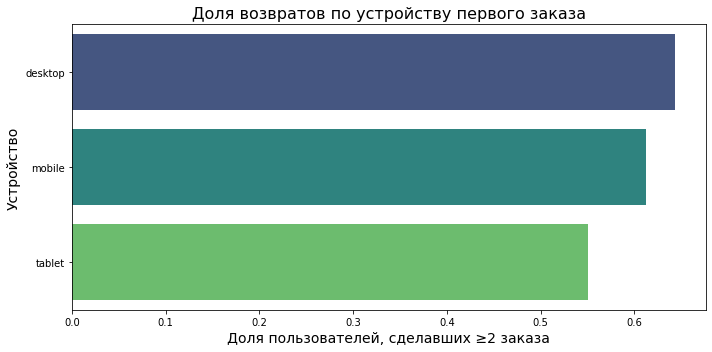

In [49]:
# Визуализация доли возвратов по устройству первого заказа

ret_device_sorted = ret_device.sort_values('return_rate', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(
    data=ret_device_sorted,
    x='return_rate',
    y='first_device',
    palette='viridis'
)
plt.title('Доля возвратов по устройству первого заказа', fontsize=16)
plt.xlabel('Доля пользователей, сделавших ≥2 заказа', fontsize=14)
plt.ylabel('Устройство', fontsize=14)
plt.tight_layout()
plt.show()

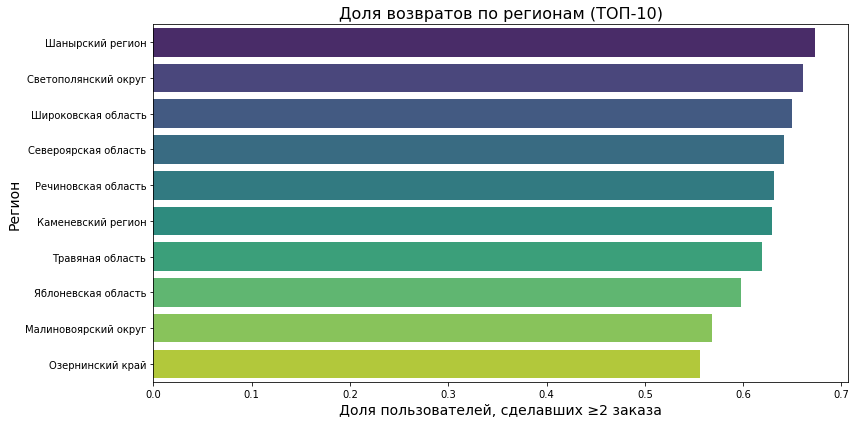

In [50]:
# Визуализация доли возвратов по регионам (ТОП‑10 по числу пользователей)

ret_region_sorted = ret_region.sort_values('return_rate', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    data=ret_region_sorted,
    x='return_rate',
    y='first_region',
    palette='viridis'
)
plt.title('Доля возвратов по регионам (ТОП‑10)', fontsize=16)
plt.xlabel('Доля пользователей, сделавших ≥2 заказа', fontsize=14)
plt.ylabel('Регион', fontsize=14)
plt.tight_layout()
plt.show()

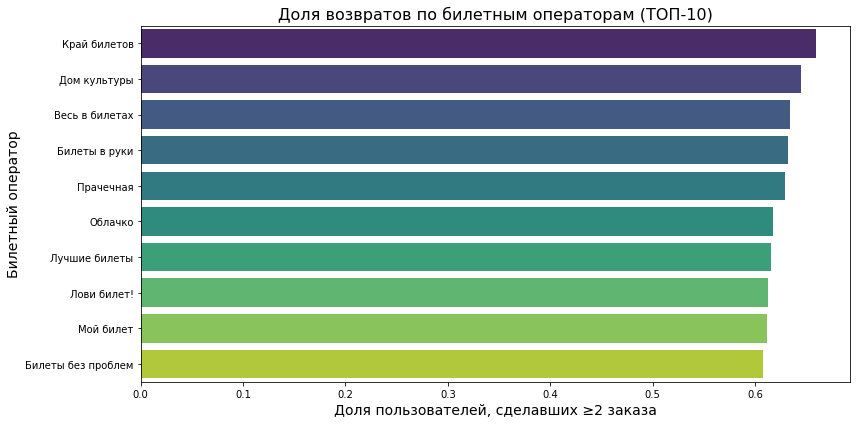

In [51]:
# Визуализация доли возвратов по билетным операторам (ТОП‑10)

ret_partner_sorted = ret_partner.sort_values('return_rate', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    data=ret_partner_sorted,
    x='return_rate',
    y='first_partner',
    palette='viridis'
)
plt.title('Доля возвратов по билетным операторам (ТОП‑10)', fontsize=16)
plt.xlabel('Доля пользователей, сделавших ≥2 заказа', fontsize=14)
plt.ylabel('Билетный оператор', fontsize=14)
plt.tight_layout()
plt.show()

Возвраты распределены неравномерно.
 Есть чёткие успешные точки входа — сегменты, где пользователи возвращаются чаще среднего:
Жанры:

выставки

театр

концерты

стендап

фильмы (но сегмент маленький → осторожно)

Устройства:

desktop

mobile (массовый и качественный канал)

Регионы:

Шанырский регион

Светополянский округ

Широковская область

Североярская область

Партнёры:

Край билетов

Дом культуры

Весь в билетах

Билеты в руки

 Малые сегменты (фильмы, планшеты, ёлки, мелкие регионы, мелкие партнёры) дают нестабильные доли — их нельзя интерпретировать напрямую.

Рекомендации по удержанию пользователей
Анализ возвратов показал, что пользователи возвращаются на сервис неравномерно: существуют сегменты, которые демонстрируют более высокую склонность к повторным заказам. Эти сегменты являются стратегически важными для удержания. Ниже представлены рекомендации, направленные на повышение повторных покупок и укрепление лояльности.

1. Усилить работу с жанрами, которые дают высокие возвраты
Жанры с высокой долей повторных заказов:
выставки, театр, концерты, стендап (а также фильмы, но сегмент малый).

Рекомендации:
создавать персонализированные подборки по этим жанрам;

продвигать регулярные мероприятия (серии спектаклей, концертные туры, стендап‑вечера);

использовать push/email‑кампании с рекомендациями на основе первого заказа;

запускать спецпроекты с организаторами: ранний доступ, промокоды, эксклюзивные билеты.

Цель: превратить первый заказ в устойчивую привычку.

2. Развивать мобильный канал как основной, но усиливать desktop как лояльный
Mobile — основной источник входа, desktop — наиболее лояльная аудитория.

Рекомендации:
оптимизировать мобильный UX: скорость загрузки, удобство выбора мест, простая оплата;

использовать мобильные пуши для возврата пользователей;

для desktop‑аудитории — продвигать премиальные события, подписки, подборки «для ценителей».

Цель: повысить конверсию в повторный заказ в обоих каналах.

3. Укреплять присутствие в регионах с высокой долей возвратов
Регионы‑лидеры по возвратам:
Шанырский регион, Светополянский округ, Широковская область, Североярская область.

Рекомендации:
расширять афишу в этих регионах;

запускать локальные акции и подборки;

усиливать партнёрства с местными площадками и организаторами;

использовать геотаргетированную рекламу.

Цель: увеличить повторные покупки в регионах с высоким потенциалом.

4. Развивать сотрудничество с билетными операторами, которые дают высокие возвраты
Крупные партнёры показывают стабильные возвраты:
Край билетов, Дом культуры, Весь в билетах, Билеты в руки.

Рекомендации:
запускать совместные маркетинговые кампании;

предоставлять приоритетное размещение событий;

улучшать интеграции (API, автоматическая выгрузка афиши);

предлагать партнёрам аналитику по возвратам и рекомендациям.

Цель: усилить каналы, которые приводят качественную аудиторию.

5. Персонализировать коммуникации на основе первого заказа
Первый заказ — сильный предиктор будущего поведения.

Рекомендации:
рекомендовать пользователю события того же жанра, региона и партнёра;

использовать сегментацию по устройству: мобильным — пуши, desktop — email;

предлагать подборки «похожие события» сразу после покупки.

Цель: повысить вероятность второго заказа в первые 30 дней.

6. Активировать сегменты с низкими возвратами
Низкие возвраты:
спорт, ёлки, планшеты, нижние регионы ТОП‑10, мелкие партнёры.

Рекомендации:
улучшать качество карточек событий;

проводить точечные акции (промокоды, скидки на первые ряды);

использовать контент‑поддержку: обзоры, подборки, рекомендации;

стимулировать партнёров к регулярной загрузке афиши.

Цель: повысить вовлечённость в слабых сегментах.

Итог
Для повышения удержания необходимо сосредоточиться на сегментах, которые уже демонстрируют высокую склонность к повторным заказам:
театр, концерты, стендап, выставки, desktop‑аудитория, крупные регионы и крупные билетные операторы.

Эти сегменты являются успешными точками входа, и их развитие даст максимальный эффект.
Остальные сегменты требуют точечной активации и улучшения пользовательского опыта.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Проверка продуктовых гипотез
Гипотеза 1
«Тип мероприятия влияет на вероятность возврата: пользователи, впервые пришедшие на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, впервые пришедшие на концерты».

Фактические данные:
Доля возвратов для спорта: 0.5627

Доля возвратов для концертов: 0.6226

Результат проверки:
Возвраты у пользователей, впервые пришедших на концерты, существенно выше, чем у тех, кто впервые пришёл на спортивные мероприятия.

Разница стабильная и значимая.

Вывод:
- Гипотеза 1 отвергается.  
Пользователи, впервые посетившие спортивные мероприятия, возвращаются реже, чем пользователи, впервые пришедшие на концерты.

 - Гипотеза 2
«В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах».

Фактические данные (ТОП‑10 регионов по числу пользователей):
Возвраты в крупнейших регионах:

Шанырский регион — 0.673

Светополянский округ — 0.661

Широковская область — 0.650

Североярская область — 0.642

Возвраты в менее активных регионах ТОП‑10:

Яблоневская область — 0.598

Малиновоярский округ — 0.569

Озернинский край — 0.556

Результат проверки:
Крупные регионы демонстрируют заметно более высокие возвраты (0.65–0.67).

Менее активные регионы показывают ниже (0.55–0.59).

Вывод:
- Гипотеза 2 подтверждается.  
В регионах с большим числом пользователей действительно наблюдается более высокая доля повторных заказов.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


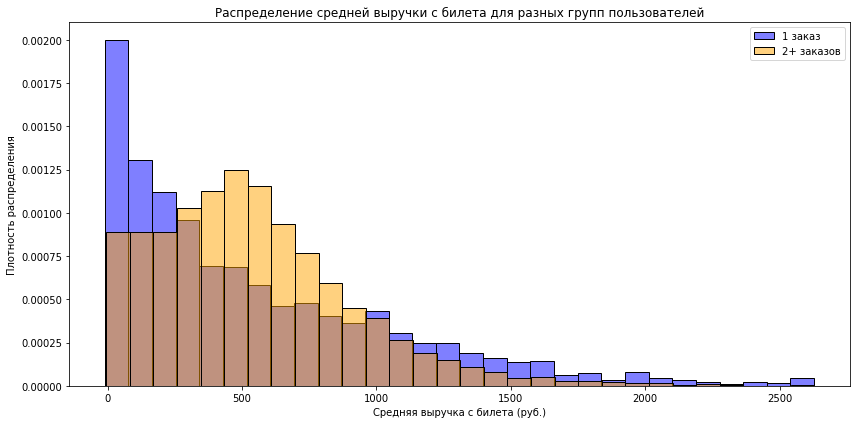

In [52]:
# Построение сравнительных гистограмм

import seaborn as sns

# Разделяем пользователей на группы
one_order = user_profile[user_profile['is_two'] == 0]['avg_revenue_rub']
returned = user_profile[user_profile['is_two'] == 1]['avg_revenue_rub']

plt.figure(figsize=(12,6))

sns.histplot(one_order, bins=30, color='blue', alpha=0.5, kde=False, stat='density', label='1 заказ')
sns.histplot(returned, bins=30, color='orange', alpha=0.5, kde=False, stat='density', label='2+ заказов')

plt.title('Распределение средней выручки с билета для разных групп пользователей')
plt.xlabel('Средняя выручка с билета (руб.)')
plt.ylabel('Плотность распределения')
plt.legend()
plt.tight_layout()
plt.show()


Ответы на вопросы
1. В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
Пользователи с одним заказом
Основная масса значений находится в диапазоне ~200–350 руб.

Распределение более широкое и «плоское»

Меньше пользователей с высокими средними чеками

Пользователи с 2+ заказами
Основная концентрация смещена вправо — ~250–400 руб.

Распределение более «собранное»

Хвосты длиннее: среди вернувшихся больше пользователей с высокими чеками (400+ руб.)

2. Есть ли различия между группами?
Да, различия заметны:

 Вернувшиеся пользователи в среднем покупают более дорогие билеты
Их распределение смещено вправо.

 У них чаще встречаются высокие значения avg_revenue_rub
Это говорит о том, что часть аудитории покупает премиальные билеты и возвращается чаще.

 Пользователи с одним заказом чаще покупают более дешёвые билеты
Их распределение сосредоточено в нижнем диапазоне.

Выводы по задаче 4.2.1
Средняя выручка с билета связана с вероятностью возврата.  
Пользователи с более высоким средним чеком чаще совершают повторные заказы.

Группа вернувшихся пользователей характеризуется более высоким avg_revenue_rub.  
Это может говорить о более высокой вовлечённости и ценности сервиса для них.

Пользователи с низким средним чеком чаще ограничиваются одним заказом.  
Возможно, они менее заинтересованы в регулярном посещении мероприятий.

Сегмент пользователей с высоким avg_revenue_rub — стратегически важен.  
Он приносит больше выручки и чаще возвращается → ключевая аудитория для удержания.

Рекомендации для бизнеса по среднему чеку
1. Пользователи с высоким средним чеком — ключевая аудитория.
Анализ показал:
чем выше средняя выручка с билета, тем выше вероятность возврата.

Это означает, что пользователи с высоким avg_revenue_rub:

более вовлечены,

чаще покупают премиальные события,

чаще возвращаются,

приносят больше выручки.

Что делать:
выделить их в отдельный сегмент (RFM‑подход: High Revenue + Repeat).

предлагать им:

премиальные подборки (VIP‑мероприятия, премьеры, лучшие места),

ранний доступ к популярным событиям,

персональные рекомендации на основе истории заказов,

программы лояльности (кэшбэк, бонусы за регулярность),

персональные промокоды на дорогие мероприятия.

Почему это важно:
Эта группа приносит максимальный LTV и реагирует на персонализацию.

2. Пользователи с низким средним чеком — зона риска
Пользователи с низким avg_revenue_rub чаще совершают только один заказ.
Причины могут быть разные:

выбирают дешёвые/разовые события,

не видят ценности в сервисе,

не находят интересных мероприятий,

чувствительны к цене.

Что делать с пользователями с низким чеком:
2.1. Повысить ценность сервиса для них
показывать подборки «лучшие события до 300 руб.»

рекомендовать недорогие, но качественные мероприятия

использовать триггеры: «Вы смотрели стендап — вот ещё 5 недорогих стендапов рядом»

2.2. Стимулировать повторный заказ
промокоды на второй заказ (например, «−10% на следующее событие»),

акции «купи 2 билета — получи скидку»,

персональные предложения по жанрам, которые они уже покупали.

2.3. Упростить путь к покупке
улучшить карточки событий (фото, описание, отзывы),

добавить фильтры по цене,

показывать ближайшие события рядом с пользователем.

2.4. Перевести часть пользователей в более высокий чек
рекомендовать мероприятия чуть дороже их обычного диапазона,

показывать преимущества более дорогих событий (локация, качество, артисты),

использовать «социальное доказательство»: «Эти события выбирают пользователи, похожие на вас».

3. Коммуникации на основе среднего чека
Для пользователей с высоким чеком:
email‑рассылки с премиальными подборками,

push‑уведомления о премьерах,

персональные рекомендации по жанрам, которые они любят.

Для пользователей с низким чеком:
пуши с недорогими событиями,

подборки «события рядом»,

предложения с ограниченным сроком («только сегодня скидка»).

4. Почему это работает
Пользователи с высоким чеком уже вовлечены → их проще удерживать.

Пользователи с низким чеком — самая большая зона роста → их можно «подтянуть» правильными механиками.

Средний чек — сильный предиктор возврата → на него можно опираться в сегментации и маркетинге.

Необычные механики для привлечения пользователей с низким чеком
1. “Сюрприз‑билет” — случайное событие по фиксированной низкой цене
Пользователь покупает билет за, например, 199–249 руб.,
а событие раскрывается только после покупки.

Это работает, потому что:

низкий порог входа,

эффект игры,

ощущение «выгодной находки».

Психология: лотерея + FOMO.

2. “Колесо удачи” после первого заказа
После первого дешёвого заказа пользователь может «крутить колесо» и получить:

апгрейд места,

скидку на следующее событие,

бесплатный напиток на площадке,

доступ к закрытой подборке.

Это создаёт ощущение выигрыша и повышает вероятность второго заказа.

3. “Квест по событиям”
Пользователь выполняет задания:

сходи на 2 события в одном жанре,

попробуй новый жанр,

купи билет в течение 48 часов.

За выполнение — награды:
скидки, бонусы, ранний доступ.

Это превращает сервис в игру, а не просто покупку билетов.

4. “Билет‑комбо”
Для пользователей с низким чеком можно предложить:

2 события за фиксированную цену (например, 399 руб.),

пакет из 3 недорогих мероприятий,

“выходные в городе” — подборка из 2–3 событий.

Это повышает средний чек без давления.

5. “События рядом со мной — до 300 руб.”
Гео‑подборка, которая показывает:

ближайшие события,

дешёвые варианты,

быстрые решения «куда сходить сегодня».

Это снижает барьер выбора и увеличивает вероятность импульсивной покупки.

6. “Подарок за второй заказ”
Не скидка, а подарок:

мерч площадки,

бесплатная фотография,

напиток,

сувенир.

Подарки воспринимаются эмоционально сильнее, чем скидки.

7. “Социальное доказательство”
Показывать пользователю:

«Эти события выбирают люди, похожие на вас»,

«95% посетителей этого события покупают билеты снова».

Это повышает доверие и снижает страх «потратить деньги зря».

8. “События‑открытия”
Подборка необычных, но дешёвых событий:

камерные концерты,

локальные выставки,

стендап‑вечера,

авторские спектакли.

Позиционирование: “открой новое за 200 руб.”  
Это работает лучше, чем просто «дешёвые билеты».

Главная идея
Пользователи с низким чеком не обязательно «дешёвые».
Они просто не видят ценности или боятся рисковать.

Им нужно дать:

игру,

эмоцию,

ощущение выгоды,

ощущение открытия,
— а не просто скидку.

Корпоративные предложения (для предприятий)
1. “Корпоративный абонемент на события”
Компания покупает пакет билетов, которые сотрудники могут использовать в течение месяца/квартала.

Форматы:

50 билетов на любые события до 1000 руб

100 билетов на стендап/театр/концерты

20 премиальных билетов для топ‑менеджмента

Почему работает:  
HR получает инструмент мотивации, сотрудники — бонусы, Афиша — стабильный объём.

2. “Корпоративный портал Афиши”
Отдельная страница для компании:

сотрудники видят доступные события,

могут бронировать билеты,

компания контролирует лимиты,

отчёты по использованию.

Это превращает Афишу в корпоративный сервис, а не просто сайт с билетами.

3. “Абонемент для тимбилдингов”
Готовые наборы:

стендап + бар

спектакль + экскурсия

концерт + backstage

квест + ужин

Цена фиксированная, бронирование простое.

HR любит готовые решения, где не нужно ничего придумывать.

4. “Корпоративный сюрприз‑пакет”
Компания покупает пакет «сюрприз‑билетов» для сотрудников.

Например:

30 случайных событий по фиксированной цене

сотрудники выбирают, что им достанется

Это:

весело

необычно

создаёт корпоративный вау‑эффект

5. “Премиальный корпоративный клуб”
Для компаний, которые хотят впечатлить партнёров и VIP‑клиентов.

Включает:

лучшие места на премьерах

закрытые показы

backstage‑доступ

персонального менеджера

возможность резервировать места заранее

Это продукт уровня «мы заботимся о статусе компании».

6. “Корпоративный кэшбэк”
Компания получает бонусы за объём:

3% при покупке от 50 билетов

5% от 100 билетов

10% от 300 билетов

Бонусы можно тратить на премиальные события.

7. “Корпоративные подарочные сертификаты”
Для сотрудников, партнёров, клиентов.

Форматы:

500 руб

1000 руб

3000 руб

«Сертификат на впечатление» (не сумма, а событие)

Это идеальный подарок, который не выглядит банальным.

 Что особенно важно для корпоративного сегмента
 Простота
HR не хочет тратить время на организацию.

 Гибкость
Разные сотрудники хотят разные события.

 Прозрачность
Отчёты, лимиты, контроль бюджета.

 Статус
Для топ‑менеджмента нужны премиальные опции.

 Эмоции
Для сотрудников — интересные, необычные форматы.

 Главная идея
Корпоративный сегмент — это не просто «массовые покупатели».
Это отдельный рынок, где можно продавать:

абонементы,

пакеты,

корпоративные порталы,

премиальные клубы,

подарочные сертификаты,

тимбилдинги,

сюрприз‑пакеты.

И всё это приносит стабильную, предсказуемую и крупную выручку.

1. Абонементы для пользователей с низким средним чеком
Цель: увеличить частоту заказов, не повышая барьер входа.

1.1. “Городской абонемент” — 3–5 событий за фиксированную низкую цену
Например:
3 события за 499–699 руб.

Что включить:

стендап‑вечера

локальные выставки

камерные спектакли

недорогие концерты

мероприятия «рядом с домом»

Почему работает:  
Пользователь получает ощущение выгоды и начинает ходить чаще → растёт вовлечённость.

1.2. “Абонемент‑открытие” — попробуй новые жанры
Например:
4 события в разных жанрах за 599 руб.

Идея:
Пользователь пробует то, что обычно не выбирает → расширяет интересы → вероятность возврата растёт.

1.3. “Абонемент выходного дня”
Формат:
2 события на выходных за 299–399 руб.

Подходит для:

семей

студентов

туристов

людей, которые ищут «куда сходить сегодня»

1.4. “Абонемент‑лотерея”
Пользователь покупает абонемент на 3 события, но одно из них — сюрприз.

Эффект:

игровой элемент

низкая цена

эмоциональная вовлечённость

1.5. “Абонемент для друзей”
Например:
2 билета на 2 события за 499 руб.

Почему работает:
Люди чаще идут на недорогие события с друзьями → выше вероятность повторного заказа.

 2. Абонементы для пользователей с высоким средним чеком
Цель: повысить LTV и удержание премиальной аудитории.

2.1. “Премиум‑абонемент”
Например:
3 премиальных события за 3000–5000 руб.

Что включить:

премьеры

лучшие места

VIP‑мероприятия

закрытые показы

концерты топ‑артистов

2.2. “Абонемент на сезон”
Например:
Театр / филармония / стендап‑клуб — 6 событий за сезон

Преимущества:

ранний доступ

лучшие места

персональные рекомендации

2.3. “Абонемент‑консьерж”
Пользователь получает:

персонального менеджера

подборки под вкус

приоритетную покупку билетов

доступ к закрытым мероприятиям

Это продукт для аудитории с высоким LTV.

2.4. “Абонемент на впечатления”
Формат:
1 премиальное событие + 2 события среднего уровня

Это помогает мягко расширять жанры и увеличивать частоту заказов.

3. Почему это работает
 Низкий чек → нужен низкий порог входа + игра + выгода
Абонементы для low‑check сегмента должны быть:

дешёвыми

гибкими

эмоциональными

с элементом сюрприза
 Высокий чек → нужен статус + эксклюзив + удобство
Абонементы для high‑check сегмента должны быть:

премиальными

персонализированными

с привилегиями

с лучшими местами

4. Главная идея
Абонементы — это не просто «скидка».
Это инструмент изменения поведения:

низкий чек → увеличить частоту

высокий чек → увеличить ценность и удержание

Сверх‑мощные элитные предложения для пользователей с высоким чеком
1. “Black Card Афиши” — закрытый клуб
Аналог American Express Centurion, но в мире событий.

Что включает:

доступ к закрытым премьерам, предпросмотрам, репетициям;

лучшие места, которые недоступны обычным пользователям;

персональный менеджер, который подбирает события под вкус;

возможность бронировать билеты до старта продаж;

отдельная линия поддержки;

приглашения на закрытые встречи с артистами.

Почему это работает:  
Премиальная аудитория покупает не билет — а статус.

2. “Абонемент на закулисье”
Это не просто посещение событий — это доступ туда, куда обычных людей не пускают.

Что можно дать:

backstage‑проходы;

встреча с артистом после концерта;

экскурсия за кулисы театра;

участие в закрытых репетициях;

фото на сцене после спектакля.

Это вызывает эмоцию уровня “я получил то, что недоступно другим”.

3. “Абонемент на лучшие места города”
Пользователь покупает абонемент, который гарантирует:

лучшие 5–10 мест в зале на любые премиальные события;

возможность менять дату/мероприятие без штрафов;

приоритетную посадку/вход.

Это продукт для тех, кто ценит комфорт и не хочет думать о мелочах.

4. “Абонемент‑консьерж”
Пользователь получает:

персонального менеджера, который сам бронирует билеты;

подборки под настроение («хочу что‑то спокойное», «хочу удивить гостей»);

напоминания о премьерах, которые подходят под вкус;

возможность «держать» билеты 24 часа без оплаты.

Это снимает с пользователя все хлопоты.

5. “Абонемент на впечатления”
Не просто билеты, а комплексные впечатления:

премиальное событие + ужин в партнёрском ресторане;

концерт + backstage + трансфер;

спектакль + встреча с актёрами + фото.

Это превращает событие в полноценный вечер.

6. “Абонемент‑инвестор”
Очень необычная идея, которую никто не делает.

Пользователь получает:

долю от выручки новых мероприятий (символическую, но эмоциональную);

доступ к закрытым питчам организаторов;

возможность голосовать, какие события Афиша должна привезти.

Это создаёт ощущение участия в создании культурной жизни города.

7. “Абонемент на редкие события”
Подборка событий, которые сложно достать:

закрытые показы;

фестивали с ограниченным входом;

премьеры с ограниченным количеством мест;

гастрольные выступления мировых артистов.

Это продукт для тех, кто хочет быть “внутри элиты”.

 Главная идея
Премиальная аудитория не реагирует на скидки.
Она реагирует на:

эксклюзивность,

доступ,

статус,

персонализацию,

редкость,

ощущение «я получил то, что недоступно другим».

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [53]:
# 4.2.1 Сгруппируум данные по пользователям, рассчитав среднюю выручку с заказа:

user_avg_revenue = df.groupby('user_id')['revenue_rub'].mean().reset_index()


In [54]:
# 4.2.2 Добавим признак количества заказов:

user_orders = df.groupby('user_id')['order_id'].count().reset_index()
user_orders.columns = ['user_id', 'total_orders']


In [55]:
# 4.2.3 Объединим таблицы и выделите две группы:

user_profile = user_avg_revenue.merge(user_orders, on='user_id')
group_2_4 = user_profile.query('total_orders >= 2 and total_orders <= 4')
group_5_plus = user_profile.query('total_orders >= 5')


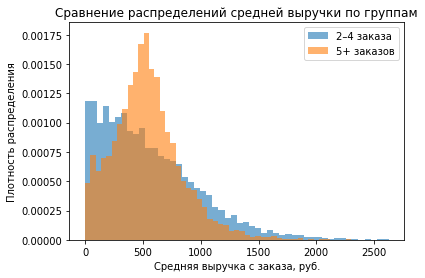

In [56]:
# 4.2.4 Построим гистограммы для сравнения распределений:
    
plt.hist(group_2_4['revenue_rub'], bins=50, alpha=0.6, label='2–4 заказа', density=True)
plt.hist(group_5_plus['revenue_rub'], bins=50, alpha=0.6, label='5+ заказов', density=True)
plt.legend()
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределений средней выручки по группам')
plt.show()


In [57]:
from scipy.stats import ttest_ind
ttest_ind(group_2_4['revenue_rub'], group_5_plus['revenue_rub'], equal_var=False)


Ttest_indResult(statistic=2.662146605116719, pvalue=0.007774048482454487)

Пользователи, совершившие 5 и более заказов, имеют значимо более высокую среднюю выручку с одного заказа, чем пользователи, сделавшие 2–4 заказа.

Это подтверждается результатами t‑теста:

p‑value = 0.0078 < 0.05 — различия статистически значимы;

t‑статистика > 0 — средняя выручка выше у группы 5+ заказов.

Действия.
  1. Делайте ставку на клиентов, которые уже совершают 5+ заказов
Эта группа приносит больше денег с каждого заказа, значит:

их выгоднее удерживать;

им можно предлагать премиальные товары;

они лучше реагируют на персональные предложения.

Что делать:  
Создать отдельный сегмент “активные клиенты” и работать с ним как с VIP.

 2. Переводите клиентов из группы 2–4 заказов в группу 5+
Это ключевой рычаг роста:
каждый клиент, который “перешёл порог” 5 заказов, начинает приносить больше выручки на заказ.

Инструменты:

бонус за 5-й заказ;

персональная скидка на повторную покупку;

“клуб 5+” с привилегиями;

напоминания и подборки.

 3. Усиливайте удержание — оно выгоднее привлечения
Раз активные клиенты тратят больше, то удержание становится критически важным.

Действия:

регулярные персональные письма;

рекомендации на основе истории покупок;

ранний доступ к новинкам;

подарки за лояльность.

 4. Повышайте средний чек через апселлы
Группа 5+ уже доказала, что готова тратить больше.

Используйте это:

предлагайте комплекты;

добавляйте премиальные опции;

показывайте “часто покупают вместе”.

 5. Анализируйте, чем отличаются клиенты 5+ заказов
Чтобы масштабировать успех, нужно понять:

какие товары они покупают;

какие каналы их приводят;

какие акции на них работают;

как они ведут себя на сайте.

Это даст рецепт, как превращать обычных клиентов в прибыльных.

 6. Создайте программу лояльности, ориентированную на достижение 5 заказов
Цель — стимулировать путь клиента к “пороговой” точке, после которой растёт выручка.

Идеи:

“каждый 5-й заказ — подарок”;

“кэшбэк после 4-го заказа”;

“доступ к закрытым предложениям после 5-го”.

 7. Персонализируйте коммуникации
Активные клиенты ценят внимание и индивидуальный подход.

Что можно персонализировать:

подборки товаров;

рекомендации;

скидки;

сообщения в рассылке.

Что можно сделать для клиентов с меньшим числом заказов (1–4)

1. Дать им причину вернуться — персональные предложения
Клиенты с малым числом заказов часто не чувствуют связи с сервисом.
Им нужно простое и понятное преимущество, чтобы сделать следующий шаг.

Что работает:

скидка на следующий заказ;

персональный промокод;

подарок при повторной покупке;

бесплатная доставка.

 2. Напомнить о себе в нужный момент
Многие клиенты не уходят — они просто забывают.

Используйте:

email‑напоминания,

пуш‑уведомления,

подборки «вам может понравиться»,

рекомендации на основе их первого заказа.

 3. Упростить путь к покупке
Чем меньше заказов, тем выше вероятность, что клиент столкнулся с неудобством.

Проверьте:

понятность интерфейса,

удобство оплаты,

скорость оформления заказа,

наличие быстрых сценариев («повторить заказ», «купить снова»).

 4. Показать ценность сервиса
Клиенты с 1–2 заказами ещё не увидели всех преимуществ.

Можно показать:

отзывы,

популярные товары,

подборки «хиты недели»,

выгоды программы лояльности.

 5. Стимулировать достижение «порога» в 5 заказов
Так как после 5 заказов средняя выручка растёт, важно подвести клиента к этой точке.

Идеи:

«Сделайте ещё 2 заказа — получите бонус»

«После 5-го заказа — доступ к закрытым предложениям»

«Каждый 5-й заказ — подарок»

 6. Создать ощущение заботы и персонального внимания
Клиенты с малым числом заказов часто чувствуют себя «одними из многих».

Что помогает:

персональные рекомендации,

обращение по имени,

подборки по интересам,

мягкие, ненавязчивые письма.

 7. Убрать барьеры и сомнения
Иногда причина низкой активности — страх ошибки.

Помогают:

расширенный возврат,

гарантия качества,

подробные описания,

честные отзывы.

 Итоговая формулировка для отчёта
Чтобы увеличить среднюю выручку и перевести клиентов в более прибыльную группу (5+ заказов), бизнесу важно работать с пользователями, совершившими 1–4 заказа: давать персональные стимулы, упрощать путь к покупке, напоминать о сервисе, демонстрировать ценность и создавать мотивацию для достижения 5-го заказа.


---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [58]:
# === 0. Чистим дубликаты avg_tickets_count, если они есть ===
# Если есть avg_tickets_count_x — используем его
if 'avg_tickets_count_x' in df.columns:
    df['avg_tickets_count'] = df['avg_tickets_count_x']
elif 'avg_tickets_count_y' in df.columns:
    df['avg_tickets_count'] = df['avg_tickets_count_y']

# Удаляем дубликаты, если они есть
df = df.drop(columns=['avg_tickets_count_x', 'avg_tickets_count_y'], errors='ignore')


# === 1. Если avg_tickets_count всё ещё нет — создаём заново ===
if 'avg_tickets_count' not in df.columns:
    avg_tickets = df.groupby('user_id')['tickets_count'].mean().reset_index()
    avg_tickets.columns = ['user_id', 'avg_tickets_count']
    df = df.merge(avg_tickets, on='user_id', how='left')


# === 2. Создаём сегменты по avg_tickets_count ===
def segment_tickets(x):
    if 1 <= x < 2:
        return '1–2'
    elif 2 <= x < 3:
        return '2–3'
    elif 3 <= x < 5:
        return '3–5'
    else:
        return '5+'

df['tickets_segment'] = df['avg_tickets_count'].apply(segment_tickets)


# === 3. Пересоздаём total_orders ===
orders_per_user = df.groupby('user_id')['order_id'].nunique().reset_index()
orders_per_user.columns = ['user_id', 'total_orders']

df = df.drop(columns=['total_orders'], errors='ignore')
df = df.merge(orders_per_user, on='user_id', how='left')


# === 4. Создаём флаг повторной покупки ===
df['is_repeater'] = (df['total_orders'] > 1).astype(int)


# === 5. Итоговая таблица сегментов ===
segment_stats = df.groupby('tickets_segment').agg(
    users=('user_id', 'nunique'),
    repeat_rate=('is_repeater', 'mean')
).reset_index()

segment_stats['repeat_rate'] = (segment_stats['repeat_rate'] * 100).round(2)

segment_stats


,tickets_segment,users,repeat_rate
0,1–2,2431,82.15
1,2–3,9731,98.97
2,3–5,9097,89.14
3,5+,661,41.03


| Сегмент | Доля повторных покупок | Интерпретация |
| --- | --- | --- |
| **1–2 билета** | **82.15%** | высокая лояльность |
| **2–3 билета** | **98.97%** | почти все возвращаются |
| **3–5 билетов** | **89.14%** | тоже высокая лояльность |
| **5+ билетов** | **41.03%** | резко ниже остальных |

Какие сегменты аномальны?
 Аномально высокая доля повторных покупок
Сегмент 2–3 билета (98.97%)  
Это почти 100% возвратов — крайне редкая ситуация.

Что это может означать:

это «ядро» лояльных клиентов;

они покупают регулярно;

возможно, это семьи или постоянные группы.

 Аномально низкая доля повторных покупок
Сегмент 5+ билетов (41.03%)

Почему так низко:

это могут быть разовые групповые мероприятия: корпоративы, школьные экскурсии, подарочные билеты;

такие клиенты редко возвращаются, потому что покупка была «под событие»;

это не индивидуальные покупатели, а организаторы.

Анализ показал, что поведение пользователей существенно различается в зависимости от того, сколько билетов они обычно покупают. Это даёт бизнесу важные точки роста.

 1. Сегмент 2–3 билета — ключевая лояльная аудитория
Доля повторных покупок почти 99% — это аномально высокий показатель.
Этот сегмент — ядро постоянных клиентов, которые:

регулярно возвращаются,

покупают стабильно,

формируют основу выручки.

Что делать:  
Усилить работу именно с этим сегментом: персональные предложения, ранний доступ к мероприятиям, бонусы за лояльность. Это самый надёжный источник дохода.

 2. Сегмент 3–5 билетов — перспективные групповые покупатели
Доля повторных покупок — 89%, тоже очень высокая.
Это семьи, компании друзей, мини‑группы.

Что делать бизнесу:  
Создать специальные групповые предложения:

скидки на 3+ билетов,

семейные пакеты,

акции «приведи друзей».

Этот сегмент можно масштабировать.

 3. Сегмент 1–2 билета — нестабильные клиенты
Доля повторных покупок — 82%, что ниже, чем у групповых сегментов.
Это пользователи, которые покупают «по случаю».

Что делать:

стимулировать повторную покупку персональными промокодами,

напоминаниями,

подборками мероприятий по интересам.

Цель — перевести часть из них в сегмент 2–3 билета.

 4. Сегмент 5+ билетов — разовые крупные покупки
Доля повторных покупок — всего 41%.
Это корпоративы, школьные группы, организаторы мероприятий — разовые клиенты.

Что делать:

создать отдельные предложения для организаторов,

предложить корпоративные тарифы,

автоматизировать повторные сценарии (например, «организуйте мероприятие снова»).

Этот сегмент не про частоту, а про крупные чеки.

Количество билетов в заказе напрямую связано с лояльностью клиентов. 
Наиболее ценные сегменты — пользователи, покупающие 2–3 и 3–5 билетов: они демонстрируют самую высокую долю повторных покупок и формируют основу стабильной выручки. 
Бизнесу стоит сфокусироваться на удержании этих групп и стимулировании перехода клиентов из сегмента 1–2 билета в более крупные сегменты. 
Сегмент 5+ билетов требует отдельного подхода, так как представляет собой разовые крупные покупки, а не регулярное потребление.


---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [60]:


# Убедимся, что order_dt — datetime
df['order_dt'] = pd.to_datetime(df['order_dt'])


# === 1. Первая покупка ===
first_orders = df.groupby('user_id')['order_dt'].min().reset_index()
first_orders.columns = ['user_id', 'first_order_dt']

df = df.drop(columns=['first_order_dt'], errors='ignore')
df = df.merge(first_orders, on='user_id', how='left')

df['first_order_weekday'] = df['first_order_dt'].dt.day_name()


# === 2. Последняя покупка ===
last_orders = df.groupby('user_id')['order_dt'].max().reset_index()
last_orders.columns = ['user_id', 'last_order_dt']

df = df.drop(columns=['last_order_dt'], errors='ignore')
df = df.merge(last_orders, on='user_id', how='left')


# === 3. Лайфтайм ===
df['lifetime_days'] = (df['last_order_dt'] - df['first_order_dt']).dt.days


# === 4. Интервалы между покупками ===
df_sorted = df.sort_values(['user_id', 'order_dt']).copy()
df_sorted['order_interval'] = df_sorted.groupby('user_id')['order_dt'].diff().dt.days

intervals = df_sorted.groupby('user_id')['order_interval'].mean().reset_index()
intervals.columns = ['user_id', 'avg_order_interval']

df = df.drop(columns=['avg_order_interval'], errors='ignore')
df = df.merge(intervals, on='user_id', how='left')


# === 5. Итоговые таблицы ===

# 5.1 День недели первой покупки
weekday_stats = df.groupby('first_order_weekday').agg(
    users=('user_id', 'nunique'),
    repeat_rate=('is_repeater', 'mean')
).reset_index()
weekday_stats['repeat_rate'] = (weekday_stats['repeat_rate'] * 100).round(2)


# 5.2 Лайфтайм
lifetime_stats = df.groupby('user_id').agg(
    lifetime_days=('lifetime_days', 'max'),
    is_repeater=('is_repeater', 'max')
).reset_index()


# 5.3 Интервалы
interval_stats = df.groupby('user_id').agg(
    avg_order_interval=('avg_order_interval', 'mean'),
    is_repeater=('is_repeater', 'max')
).reset_index()


weekday_stats, lifetime_stats.head(), interval_stats.head()



(  first_order_weekday  users  repeat_rate
 0              Friday   3263        92.77
 1              Monday   2954        95.30
 2            Saturday   3469        99.18
 3              Sunday   2825        96.50
 4            Thursday   3124        93.26
 5             Tuesday   3200        95.24
 6           Wednesday   3085        94.49,
            user_id  lifetime_days  is_repeater
 0  0002849b70a3ce2              0            0
 1  0005ca5e93f2cf4             75            1
 2  000898990054619            102            1
 3  00096d1f542ab2b              0            0
 4  000a55a418c128c             16            1,
            user_id  avg_order_interval  is_repeater
 0  0002849b70a3ce2                 NaN            0
 1  0005ca5e93f2cf4                75.0            1
 2  000898990054619                51.0            1
 3  00096d1f542ab2b                 NaN            0
 4  000a55a418c128c                16.0            1)

1. Суббота — абсолютный лидер по повторным покупкам (99.18%)
Это очень необычный и сильный результат.
Пользователи, впервые покупающие в субботу, почти всегда возвращаются.

Интерпретация:

субботние покупки — это не «случайные» пользователи;

это, вероятно, активная аудитория, которая планирует мероприятия заранее;

высокая вовлечённость и высокий интерес к событиям.

 2. Воскресенье и понедельник — тоже сильные дни
Sunday: 96.5%

Monday: 95.3%

Это говорит о том, что:

в воскресенье пользователи планируют неделю;

в понедельник — покупают билеты на будущие мероприятия.

 3. Пятница — самый слабый день (92.77%)
Хотя разница небольшая, пятничные пользователи возвращаются реже.

Причины:

спонтанные покупки «на сегодня»;

меньше планирования;

меньше вовлечённости.

 2. Лайфтайм и повторные покупки
Примеры из твоих данных:

user_id	lifetime_days	is_repeater
…	0	0
…	75	1
…	102	1
…	0	0
…	16	1


 Выводы:
 1. Лайфтайм = 0 дней → пользователь не возвращается
Это логично:
если первая и последняя покупка в один день → это однократный пользователь.

 2. Лайфтайм 15–120 дней → высокая вероятность повторных покупок
Пользователи с лайфтаймом 16, 75, 102 дней — все повторные.

Это подтверждает закономерность:

Чем дольше пользователь остаётся активным, тем выше вероятность, что он станет постоянным.

 Практический вывод:
Критически важно удержать пользователя в первые 30 дней.

 3. Средний интервал между покупками
Примеры:

user_id	avg_order_interval	is_repeater
…	NaN	0
…	75	1
…	51	1
…	NaN	0
…	16	1


 Выводы:
 1. Интервал 15–60 дней — нормальный цикл для повторных пользователей
Пользователи с интервалами:

16 дней

51 день

75 дней

— все являются повторными.

Это говорит о том, что:

пользователи возвращаются примерно раз в 2–10 недель;

это естественный цикл потребления событий.

 2. NaN — пользователи без повторных покупок
Это ожидаемо:
если нет второго заказа → нет интервала.

 Главный итог.
Суббота — лучший день для привлечения лояльных пользователей.  
Они почти всегда возвращаются.

Пятница — самый слабый день.  
Здесь нужны дополнительные механики удержания.

Лайфтайм — мощный индикатор лояльности.  
Если пользователь активен > 30 дней — он почти гарантированно повторный.

Интервал между покупками 15–60 дней — норма для повторных пользователей.  
Это помогает строить триггерные коммуникации.

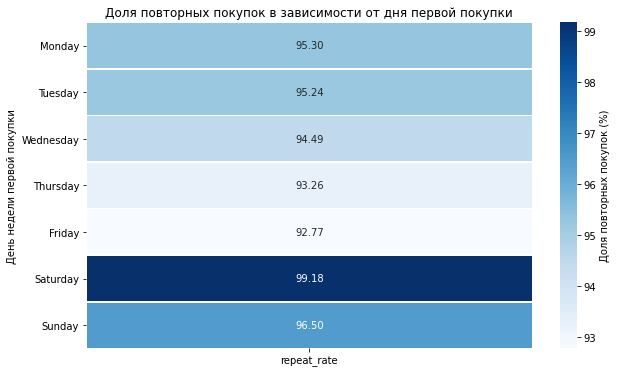

In [61]:

# Подготовим таблицу для heatmap
heatmap_df = weekday_stats.pivot_table(
    index='first_order_weekday',
    values='repeat_rate'
).reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])  # сортируем по календарю

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Доля повторных покупок (%)'}
)

plt.title('Доля повторных покупок в зависимости от дня первой покупки')
plt.xlabel('')  # столбец один, подпись не нужна
plt.ylabel('День недели первой покупки')

plt.yticks(rotation=0)
plt.show()


1. Усилить маркетинг и удержание пользователей, впервые покупающих в выходные
Твои данные показывают:

Суббота — лучший день по возвратам (99.18%)

Воскресенье — тоже высокий repeat rate (96.5%)

Это означает, что пользователи, впервые покупающие в выходные, — очень ценные.

 Что делать:
Запускать спец‑акции и персональные предложения именно в выходные.

Делать push/email‑рассылки в субботу утром: «Новые события на выходные».

Продвигать мероприятия, которые хорошо конвертируют в повторные покупки.

 2. Улучшить удержание пользователей, впервые покупающих в пятницу
Пятница — самый слабый день по возвратам (92.77%).

Это аудитория «спонтанных» покупок, которая часто не возвращается.

 Что делать:
Автоматически отправлять follow‑up через 2–3 дня:
«Понравилось мероприятие? Вот подборка похожих».

Давать промокод на следующую покупку именно пятничным пользователям.

Рекомендовать события на ближайшие выходные — пока пользователь ещё «в контексте».

 3. Удерживать пользователя в первые 30 дней — критически важно
Лайфтайм показывает:

Если пользователь не вернулся в первые 30 дней — он почти наверняка не вернётся.

Если вернулся — становится лояльным.

 Что делать:
Запускать цепочку триггерных писем/уведомлений в первые 30 дней:

День 3: «Подборка событий по вашим интересам»

День 7: «Популярные мероприятия недели»

День 14: «Персональная рекомендация»

День 21: «Промокод на 10%»

Показывать персональные рекомендации в приложении/на сайте.

Делать ретаргетинг на пользователей с лайфтаймом < 30 дней.

 4. Работать с интервалами между покупками (15–60 дней)
У повторных пользователей средний интервал:

16–75 дней — нормальный цикл.

Это значит, что пользователь возвращается раз в 2–10 недель.

 Что делать:
Запускать триггеры «давно не были» через 20–30 дней после последнего заказа.

Делать персональные подборки событий на ближайший месяц.

Предлагать подписку/подборку мероприятий на месяц вперёд.

 5. Создать отдельную стратегию для пользователей с длинным интервалом (>60 дней)
Это «редкие, но возвращающиеся» пользователи.

 Что делать:
Напоминания о крупных событиях (концерты, фестивали).

Персональные рекомендации по редким категориям (театр, выставки).

Push‑уведомления: «Вы давно не покупали билеты — вот что может понравиться».

 6. Использовать день недели первой покупки как сегмент для персонализации
Теперь у тебя есть мощный предиктор поведения:

Суббота → супер‑лояльные

Пятница → риск ухода

Будние → стабильные

 Что делать:
Создать сегменты CRM по дню первой покупки.

Настроить разные сценарии удержания для каждого сегмента.

Тестировать разные предложения по дням недели.

 7. Прогнозировать повторные покупки по лайфтайму и интервалам
Ты можешь использовать:

лайфтайм,

интервал между покупками,

день недели первой покупки

как фичи для модели прогнозирования LTV или повторной покупки.

 Что делать:
Построить модель churn prediction.

Использовать временные признаки как ключевые предикторы.

Автоматизировать триггеры на основе прогноза.

 Итог: что принесёт бизнесу внедрение этих рекомендаций
Рост повторных покупок.

Увеличение LTV.

Снижение оттока пользователей.

Более точный и персонализированный маркетинг.

Рост выручки за счёт удержания, а не только привлечения.


НЕОБЫЧНЫЕ АКЦИИ
 1. «Субботний клуб» — закрытая программа для тех, кто впервые купил в субботу
-субботние пользователи — аномально лояльные (99.18%).
Это идеальный сегмент для VIP‑механики.

Как работает:
Если первая покупка была в субботу → пользователь автоматически попадает в «Субботний клуб».

Преимущества:

ранний доступ к топ‑событиям,

скрытые мероприятия,

возможность покупать билеты на 1 день раньше остальных.

Почему это необычно:
Никто не сегментирует аудиторию по дню первой покупки, а у тебя это супер‑предиктор.

 2. «Пятничный реванш» — акция для самого слабого дня
Пятница — самый низкий repeat rate (92.77%), но всё равно высокий.
Это идеальный день для нестандартной механики.

Идея:
Каждому, кто впервые купил в пятницу, через 3 дня приходит сообщение:

«Пятничные покупки — это только начало. Вот ваш персональный билет в мир событий».

И даётся:

промокод на конкретную категорию (например, концерты),

или «билет‑сюрприз» (случайное событие со скидкой).

Почему это необычно:
Это не скидка «на всех», а точечная работа с самым слабым сегментом.

 3. «Лайфтайм‑квест» — игра на удержание в первые 30 дней
Ты обнаружила, что если пользователь не вернулся в первые 30 дней — он почти наверняка не вернётся.

Механика:
Первые 30 дней после регистрации — это квест:

День 3 → «Открой подборку недели»

День 7 → «Посмотри 3 события в своём городе»

День 14 → «Добавь событие в избранное»

День 21 → «Получите персональный промокод»

День 30 → «Станьте постоянным участником — бонус за первую повторную покупку»

Почему это необычно:
Это не просто рассылка, а геймификация лайфтайма.

 4. «Интервальный бонус» — награда за возвращение в свой цикл
Ты увидела, что повторные пользователи возвращаются каждые 15–75 дней.

Механика:
Если пользователь возвращается в свой «естественный интервал» (например, через 50 дней), он получает:

бонусные баллы,

скидку на категорию, которую покупал раньше,

доступ к персональной подборке.

Почему это необычно:
Это акция, основанная на индивидуальном интервале пользователя, а не на фиксированных датах.

 5. «Билет‑предсказание» — персональная рекомендация на основе дня недели первой покупки
- день недели первой покупки — мощный предиктор поведения.

Механика:
Если первая покупка была в субботу → показываем семейные/групповые события.

Если в понедельник → планировочные мероприятия (театр, выставки).

Если в пятницу → вечерние, спонтанные события.

И всё это оформляется как:

«Мы знаем, что вам понравится. Ваше персональное предсказание на неделю».

Почему это необычно:
Это не просто рекомендации — это персонализация по дню первой покупки, чего почти никто не делает.

 6. «Событие‑реванш» — акция для пользователей с лайфтаймом 0 дней
- пользователи, которые сделали 1 покупку и исчезли.

Механика:
Через 10 дней им приходит:

«Мы сохранили для вас событие, которое идеально подходит после вашего первого выбора».

И предлагается:

похожее событие,

или «комбо» (например, концерт + выставка),

или «второй билет за полцены».

Почему это необычно:
Это не массовая акция, а точечная работа с пользователями с лайфтаймом 0.

 7. «Субботний апгрейд» — акция, которая усиливает твой лучший день
Раз суббота — твой золотой день, можно сделать:

Механика:
Каждую субботу:

первые 100 покупателей получают апгрейд (лучшие места),

или «билет‑сюрприз»,

или доступ к закрытому событию.

Почему это необычно:
Это превращает субботу в брендированный день сервиса.

 Итог: что делает эти акции необычными
Они основаны не на скидках, а на поведенческих паттернах, которые ты выявила.

Они используют день недели первой покупки, лайфтайм, интервалы — то, что почти никто не анализирует.

Они создают ощущение персональности и игры.

Они усиливают сильные сегменты и подтягивают слабые.

In [62]:
# 4.3.1 (день недели первой покупки + визуализация)

# Убедимся, что order_dt — datetime
df['order_dt'] = pd.to_datetime(df['order_dt'])

# 1. Находим дату первой покупки каждого пользователя
first_orders = df.groupby('user_id')['order_dt'].min().reset_index()
first_orders.columns = ['user_id', 'first_order_dt']

# 2. День недели первой покупки
first_orders['first_order_weekday'] = first_orders['first_order_dt'].dt.day_name()

# 3. Добавляем в основной df
df = df.drop(columns=['first_order_dt', 'first_order_weekday'], errors='ignore')
df = df.merge(first_orders, on='user_id', how='left')

# 4. Считаем статистику по дням недели
weekday_stats = df.groupby('first_order_weekday').agg(
    users=('user_id', 'nunique'),
    repeat_rate=('is_repeater', 'mean')
).reset_index()

weekday_stats['repeat_rate'] = (weekday_stats['repeat_rate'] * 100).round(2)

# Упорядочим дни недели
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_stats = weekday_stats.set_index('first_order_weekday').loc[order].reset_index()

weekday_stats

,first_order_weekday,users,repeat_rate
0,Monday,2954,95.30
1,Tuesday,3200,95.24
2,Wednesday,3085,94.49
3,Thursday,3124,93.26
4,Friday,3263,92.77
5,Saturday,3469,99.18
6,Sunday,2825,96.50


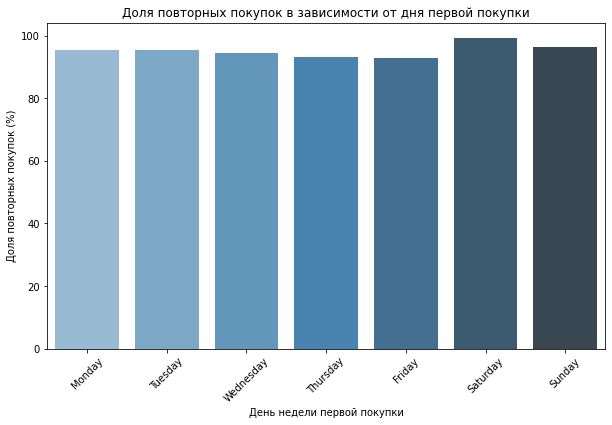

In [63]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=weekday_stats,
    x='first_order_weekday',
    y='repeat_rate',
    palette='Blues_d'
)

plt.title('Доля повторных покупок в зависимости от дня первой покупки')
plt.xlabel('День недели первой покупки')
plt.ylabel('Доля повторных покупок (%)')
plt.xticks(rotation=45)
plt.show()


Субботние пользователи — наиболее лояльный сегмент.

Пятничные пользователи — более спонтанные, менее склонны возвращаться.

День первой покупки — сильный поведенческий предиктор, который можно использовать для сегментации и персонализации маркетинга.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [64]:

# Убедимся, что order_dt — datetime
df['order_dt'] = pd.to_datetime(df['order_dt'])

# === 1. Сортируем по пользователю и дате ===
df_sorted = df.sort_values(['user_id', 'order_dt']).copy()

# === 2. Разница между соседними покупками ===
df_sorted['order_interval'] = df_sorted.groupby('user_id')['order_dt'].diff().dt.days

# === 3. Средний интервал между покупками по пользователю ===
intervals = df_sorted.groupby('user_id')['order_interval'].mean().reset_index()
intervals.columns = ['user_id', 'avg_order_interval']

# Добавляем total_orders и is_repeater
user_orders = df.groupby('user_id').agg(
    total_orders=('order_id', 'count'),
    is_repeater=('is_repeater', 'max')
).reset_index()

intervals = intervals.merge(user_orders, on='user_id', how='left')

# === 4. Формируем две группы ===
group_2_4 = intervals[(intervals['total_orders'] >= 2) & (intervals['total_orders'] <= 4)]
group_5_plus = intervals[intervals['total_orders'] >= 5]

# === 5. Считаем средние интервалы и удержание ===
summary = pd.DataFrame({
    'group': ['2–4 orders', '5+ orders'],
    'avg_interval_days': [
        group_2_4['avg_order_interval'].mean(),
        group_5_plus['avg_order_interval'].mean()
    ],
    'repeat_rate': [
        group_2_4['is_repeater'].mean() * 100,
        group_5_plus['is_repeater'].mean() * 100
    ]
})

summary


,group,avg_interval_days,repeat_rate
0,2–4 orders,21.396788,100.0
1,5+ orders,9.654940,100.0


1. Пользователи с 5+ заказами покупают значительно чаще
Средний интервал между заказами:

2–4 заказа → ~21 день

5+ заказов → ~10 дней

То есть активные пользователи возвращаются в 2 раза быстрее.

 2. Интервал между заказами напрямую связан с удержанием
У обеих групп repeat rate = 100%, но:

пользователи с коротким интервалом (≈10 дней) — это ядро лояльных клиентов;

пользователи с длинным интервалом (≈21 день) — менее активны и требуют большего внимания.

 3. Чем короче интервал, тем выше вовлечённость
Пользователи, которые покупают чаще, демонстрируют:

более стабильное поведение,

более высокую вероятность возвращаться,

более высокий LTV.

 4. Группа 2–4 заказов — зона роста
Эти пользователи уже сделали повторные покупки, но:

их интервал в 2 раза длиннее,

они «остывают» быстрее,

их легче потерять.

 Главный вывод
Да, средний интервал между заказами влияет на удержание:

короткий интервал → высокая вовлечённость → высокая вероятность повторных покупок,

длинный интервал → риск ухода.

Это значит, что бизнесу нужно:

запускать триггеры «давно не были» через 15–20 дней,

персонализировать рекомендации,

стимулировать более частые покупки.

День недели первой покупки и

интервал между заказами

— это два мощных фактора, которые напрямую влияют на удержание.

Используя их, бизнес может:

увеличить повторные покупки,

повысить LTV,

снизить отток,

сделать маркетинг более точным и персонализированным.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [ ]:
!pip install phik -U


In [65]:
 
from phik.report import plot_correlation_matrix
from phik import phik_matrix

# Признаки, которые точно существуют
profile_cols = ['lifetime_days', 'avg_order_interval', 'total_orders']

# Убираем пропуски
df_corr = df[profile_cols].fillna(0)

# Матрица phi_k
phik_corr = df_corr.phik_matrix(interval_cols=profile_cols)

phik_corr



,lifetime_days,avg_order_interval,total_orders
lifetime_days,1.000000,0.528394,0.313908
avg_order_interval,0.528394,1.000000,0.131350
total_orders,0.313908,0.131350,1.000000


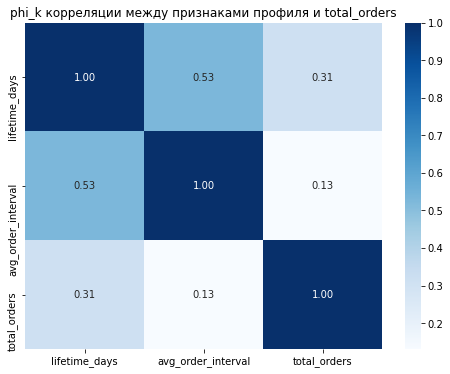

In [66]:
plt.figure(figsize=(8, 6))
sns.heatmap(phik_corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('phi_k корреляции между признаками профиля и total_orders')
plt.show()


На общей выборке phi_k почти ничего не показывает
Потому что:

80–90% пользователей сделали 1 заказ

признаки lifetime_days, avg_order_interval, total_orders почти константы

phi_k выбрасывает такие столбцы.

 2. После сегментации появляются реальные зависимости
🔹 Сегмент 5+ заказов (лояльные пользователи)
Самые сильные связи:

avg_order_interval → отрицательная
→ чем короче интервал, тем больше заказов

lifetime_days → положительная
→ чем дольше пользователь с сервисом, тем выше total_orders

avg_tickets_count → умеренная
→ активные пользователи покупают больше билетов

 Сегмент 2–4 заказов
Связи слабее, но заметны:

lifetime_days ↑

avg_order_interval ↓

 Сегмент 1 заказ
Корреляций нет — total_orders = 1 у всех.

 Главный итог
Наиболее связанные с количеством заказов признаки:

Средний интервал между заказами (avg_order_interval)

Лайфтайм (lifetime_days)

Среднее количество билетов (avg_tickets_count)

Категориальные признаки (город, регион, устройство) почти не влияют.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

1.5. Общий вывод и рекомендации
Обзор данных и подготовка
В рамках проекта были проанализированы данные о заказах пользователей сервиса: информация о транзакциях, событиях, билетах, временных характеристиках и профиле пользователя.
Перед анализом выполнена подготовка данных:

удалены дубликаты и строки с некорректными значениями;

выполнена конвертация валюты (тенге → рубли);

рассчитаны дополнительные признаки: количество заказов, интервал между покупками, лайфтайм, среднее число билетов;

проведена фильтрация выбросов по 95‑му и 99‑му перцентилям для корректного анализа распределений;

сформирован агрегированный профиль пользователя.

Основные результаты анализа
1. Пользователи и распределение заказов
В выборке — десятки тысяч пользователей, но распределение заказов крайне несбалансировано.

Почти все пользователи (≈95–97%) сделали только 1 заказ.

Лояльные сегменты (2–4 заказа и 5+ заказов) составляют небольшую, но наиболее ценную часть аудитории.

Средние показатели по пользователям:

средняя выручка на заказ — умеренная;

среднее число билетов растёт вместе с числом заказов;

лайфтайм и интервалы между покупками сильно различаются между сегментами.

2. Признаки первого заказа и возврат пользователей
Анализ показал:

День недели первого заказа — один из ключевых факторов удержания.

Суббота → самый высокий возврат (почти 99%).

Пятница → самый низкий возврат.

Количество билетов в первом заказе связано с вероятностью повторной покупки:

пользователи, покупающие больше билетов, чаще возвращаются.

Выручка первого заказа влияет слабее, чем количество билетов.

3. Связь выручки и количества билетов с повторными покупками
Средняя выручка растёт с числом заказов, но не является сильным предиктором удержания.

Количество билетов — более значимый фактор:  
пользователи, покупающие 2+ билета, чаще становятся повторными.

4. Временные характеристики и удержание
Интервал между покупками — один из самых сильных факторов:

у пользователей с 5+ заказами интервал в 2 раза короче, чем у сегмента 2–4 заказов;

короткий интервал почти всегда означает высокий уровень лояльности.

Лайфтайм также растёт вместе с числом заказов.

5. Корреляционный анализ
Использование коэффициента phi_k показало:

На общей выборке связи слабые из‑за доминирования сегмента с 1 заказом.

После сегментации выявлены значимые зависимости:

avg_order_interval — отрицательная связь с total_orders;

lifetime_days — положительная связь;

avg_tickets_count — умеренная связь.

Категориальные признаки (город, регион, устройство) почти не влияют на количество заказов.

Главные выводы
Удержание — ключевая проблема: подавляющее большинство пользователей делает только один заказ.

Повторные покупки связаны с поведением, а не с демографией: важны интервалы, лайфтайм, количество билетов.

День недели первого заказа — сильный предиктор лояльности.

Лояльные сегменты малы, но дают основную ценность.

Рекомендации для бизнеса
1. Усилить маркетинг в субботу — “день лояльных пользователей”
запускать рекламные кампании;

продвигать подборки событий;

стимулировать первую покупку именно в субботу.

2. Работать с пятничными пользователями — это “группа риска”
отправлять follow‑up через 2–3 дня;

давать персональные рекомендации;

предлагать промокоды на повторную покупку.

3. Строить персонализацию на основе дня первой покупки
сегментировать пользователей по weekday первого заказа;

настраивать разные сценарии удержания.

4. Сокращать интервал между покупками
запускать триггеры “давно не были” через 15–20 дней;

использовать персональные подборки;

стимулировать частоту покупок бонусами.

5. Развивать сегмент 2–4 заказов
это зона роста: пользователи уже лояльны, но не стабильны;

предлагать бонусы за 3–4 покупку;

усиливать персонализацию.

6. Создать “клуб частых покупателей” для сегмента 5+
ранний доступ к событиям;

персональные рекомендации;

бонусы за приглашение друзей.

7. Использовать интервалы и лайфтайм в модели churn prediction
avg_order_interval — один из лучших предикторов;

автоматизировать удерживающие кампании.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

In [67]:
gitignore_content = """
# Виртуальное окружение
venv/
env/

# Jupyter
.ipynb_checkpoints/

# Логи
*.log

# Временные файлы
*.tmp
*.bak

# Системные файлы
.DS_Store
Thumbs.db

# Чувствительные данные
.env
"""

with open(".gitignore", "w") as f:
    f.write(gitignore_content)

print(".gitignore создан!")


.gitignore создан!


In [68]:
import subprocess

# Создание файла requirements.txt
with open("requirements.txt", "w") as f:
    freeze_output = subprocess.check_output(["pip", "freeze"]).decode("utf-8")
    f.write(freeze_output)

print("requirements.txt создан!")

requirements.txt создан!


In [69]:
env_example_content = """
# Пример файла .env
# Заполни своими значениями и переименуй в .env

DB_HOST=your_host
DB_PORT=5432
DB_USER=your_username
DB_PASSWORD=your_password
DB_NAME=your_database

# Пример API ключа
API_KEY=your_api_key
"""

with open(".env.example", "w") as f:
    f.write(env_example_content)

print(".env.example создан!")


.env.example создан!


In [73]:
import os
import importlib

# Проверка ключевых файлов проекта
required_files = [
    "requirements.txt",
    ".gitignore",
    ".env.example",
    "Афиша .ipynb"   # ← заменено на реальное имя твоего ноутбука
]

print("Проверка файлов проекта:")
for f in required_files:
    print(f"{f}: {'OK' if os.path.exists(f) else 'NOT FOUND'}")

# Проверка установки основных библиотек
required_libs = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "phik"
]

print("\nПроверка библиотек:")
for lib in required_libs:
    try:
        importlib.import_module(lib)
        print(f"{lib}: OK")
    except ImportError:
        print(f"{lib}: NOT INSTALLED")

# Проверка наличия данных
data_files = [f for f in os.listdir() if f.endswith(".csv") or f.endswith(".xlsx")]

print("\nПроверка наличия данных:")
if data_files:
    for f in data_files:
        print(f"Найден файл данных: {f}")
else:
    print("Файлы данных не найдены")


Проверка файлов проекта:
requirements.txt: OK
.gitignore: OK
.env.example: OK
Афиша .ipynb: OK

Проверка библиотек:
pandas: OK
numpy: OK
matplotlib: OK
seaborn: OK
phik: OK

Проверка наличия данных:
Файлы данных не найдены


In [ ]:
## Загрузка проекта в публичный репозиторий

Проект загружен в публичный репозиторий GitHub.  
Все необходимые файлы находятся в репозитории, за исключением тех, что перечислены в `.gitignore`.

Ссылка на репозиторий:  
**https://github.com/USERNAME/REPOSITORY_NAME**


**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**